In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.product import visualise_heat_pump_performance, show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap, show_brand_by_product_type_heatmap


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 37,008 quotes from 25,716 customers


In [2]:
#customers = aggregate_customer(df_clean)

In [3]:
all_customers = pd.read_csv('customer_master_data.csv')

In [4]:

# Using quarter column (if you have it)
customers_2025_q4 = all_customers[
    (all_customers['year'] == 2025) & 
    (all_customers['quarter'] == 4)
]

# Using date range
customers_2025_q4 = all_customers[
    (all_customers['first_quote_date'] >= '2025-10-01') & 
    (all_customers['first_quote_date'] <= '2025-12-31')
]

print(f"Q4 2025 customers: {len(customers_2025_q4):,}")

Q4 2025 customers: 2,867


In [5]:
customers = customers_2025_q4


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.305729            1920            587.0
True                      0.407603             947            386.0

Chi-square p-value: 7.604283e-08
Statistically significant: YES

Conversion without issues: 30.57%
Conversion with issues: 40.76%
Difference: 10.2 percentage points
Customer-level finding: +10.2 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.32
  With issues: 1.48
  Ratio: 1.12x

avg_quote_amount:
  No issues: 5662.83
  With issues: 10339.86
  Ratio: 1.83x

max_quote_amount:
  No issues: 5967.72
  With issues: 11068.71
  Ratio: 1.85x

customer_duration_days:
  No issues: 2.47
  With issues: 4.04
  Ratio: 1.63x

price_range:
  No issues: 674.05
  With issues: 1387.49
  Ratio: 2.06x

multiple_quotes:
  No issues: 0

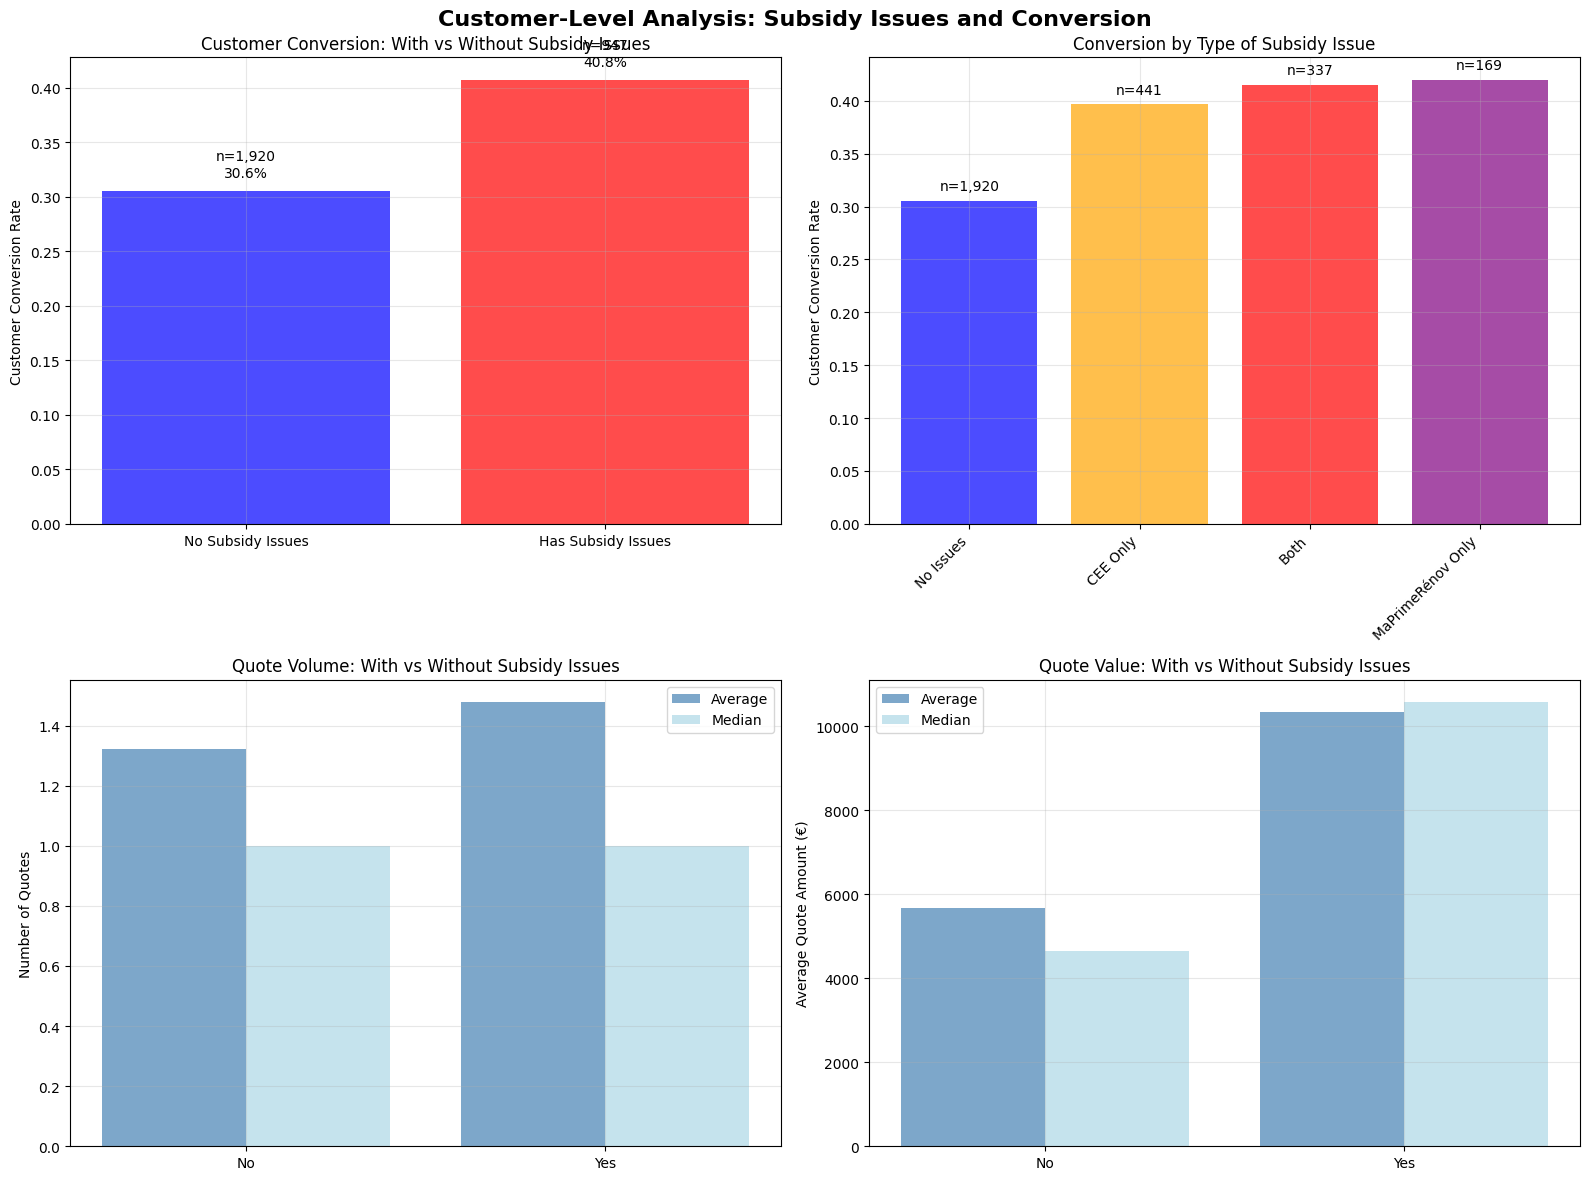


Policy Suspension Impact

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251
Unique values in during_suspension: [False]

⚠️  Only data during normal periods available

Conversion during subsidy suspensions:
                    mean  count
Normal Periods  0.337676   2763


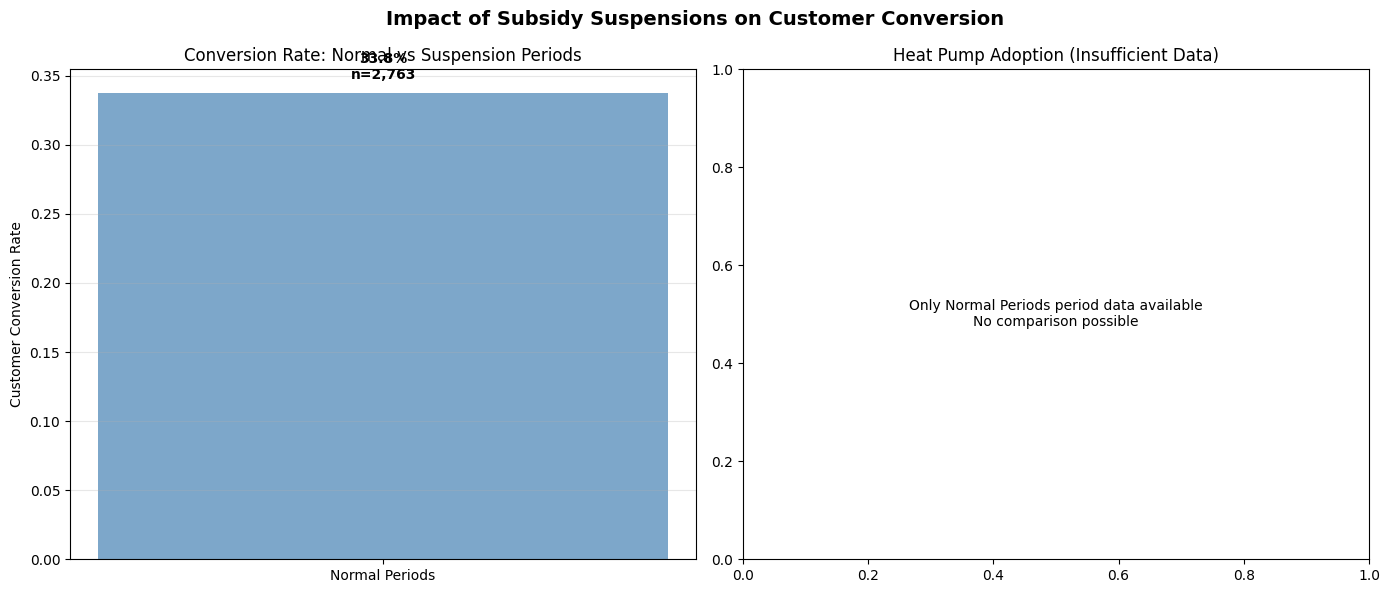

Unique values in main_product_family:
main_product_family
Chaudière                           968
Poêle                               604
Pompe à chaleur                     531
Climatisation                       493
ECS : Chauffe-eau ou adoucisseur    128
Appareil hybride                     54
Photovoltaïque                       34
Autres                               21
Produit VMC                          12
Emetteur de chauffage  ou chappe     11
Plomberie Sanitaire                   8
Unknown                               3
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           968
Poêle                               604
Pompe à chaleur                     531
Climatisation                       493
ECS : Chauffe-eau ou adoucisseur    128
Appareil hybride                     54
Photovoltaïque                       34
Autres                               21
Produit VMC                          12
Emetteur de chauffage  ou chappe     11
N

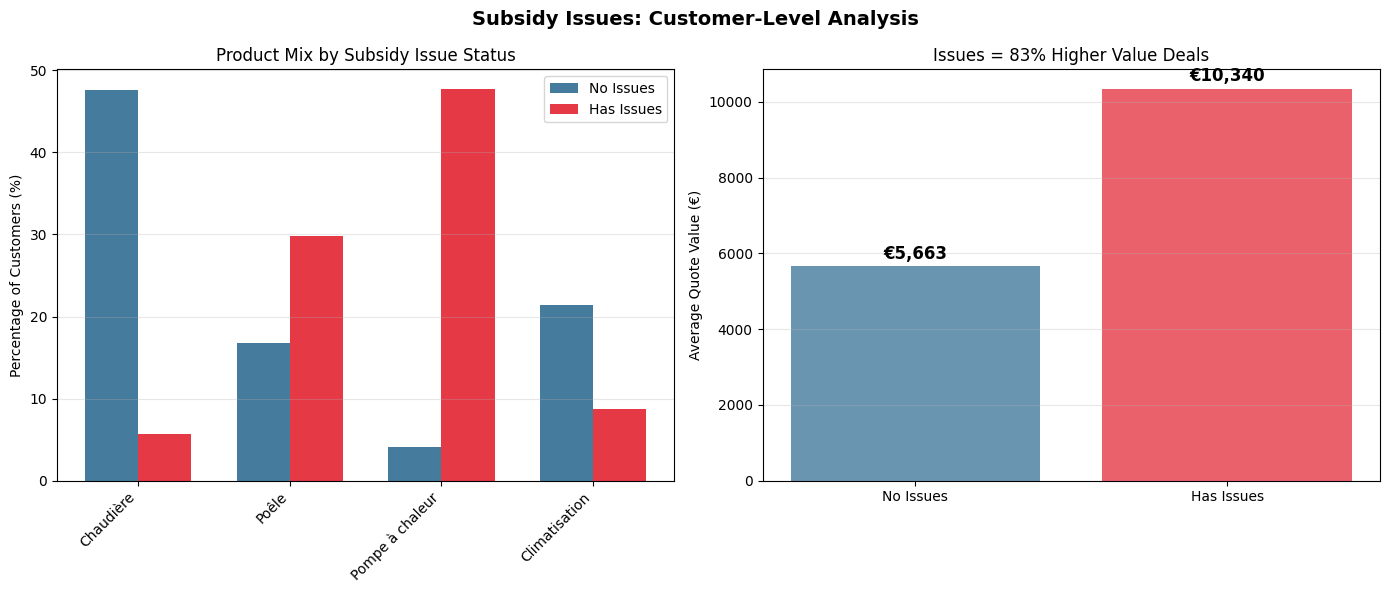


Threshold effect

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251


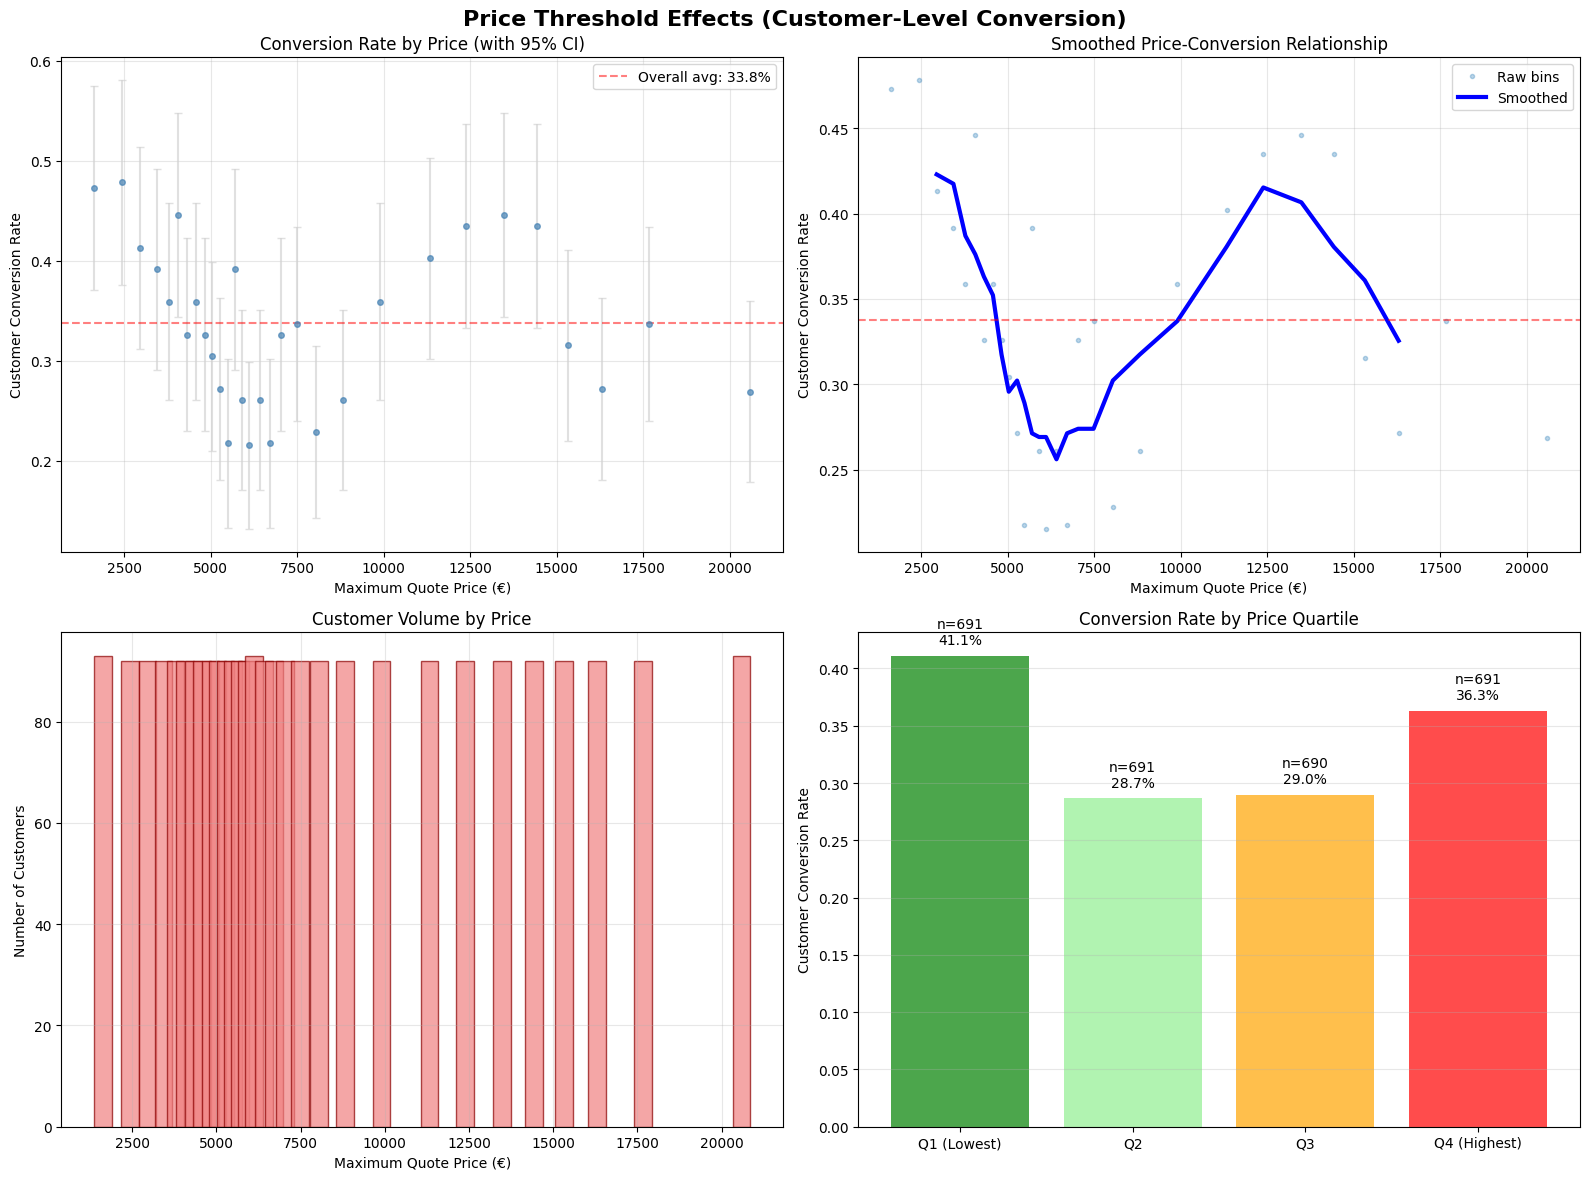


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 41.1% (n=691)
  Q2: 28.7% (n=691)
  Q3: 29.0% (n=690)
  Q4 (Highest): 36.3% (n=691)

Difference between lowest and highest quartile: 4.8 percentage points

Sweet spots (above-average conversion):
  €1,630: 47.3% (n=93)
  €2,441: 47.8% (n=92)
  €2,952: 41.3% (n=92)
  €3,435: 39.1% (n=92)
  €3,781: 35.9% (n=92)
  €4,067: 44.6% (n=92)
  €4,577: 35.9% (n=92)
  €5,706: 39.1% (n=92)
  €9,902: 35.9% (n=92)
  €11,326: 40.2% (n=92)
  €12,390: 43.5% (n=92)
  €13,489: 44.6% (n=92)
  €14,428: 43.5% (n=92)

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
price_quartile                                                         
Q1_Low                   21.8    47.7        0.3   20.4    9.5      0.3
Q2_MidLow                14.2    40.6        0.3    

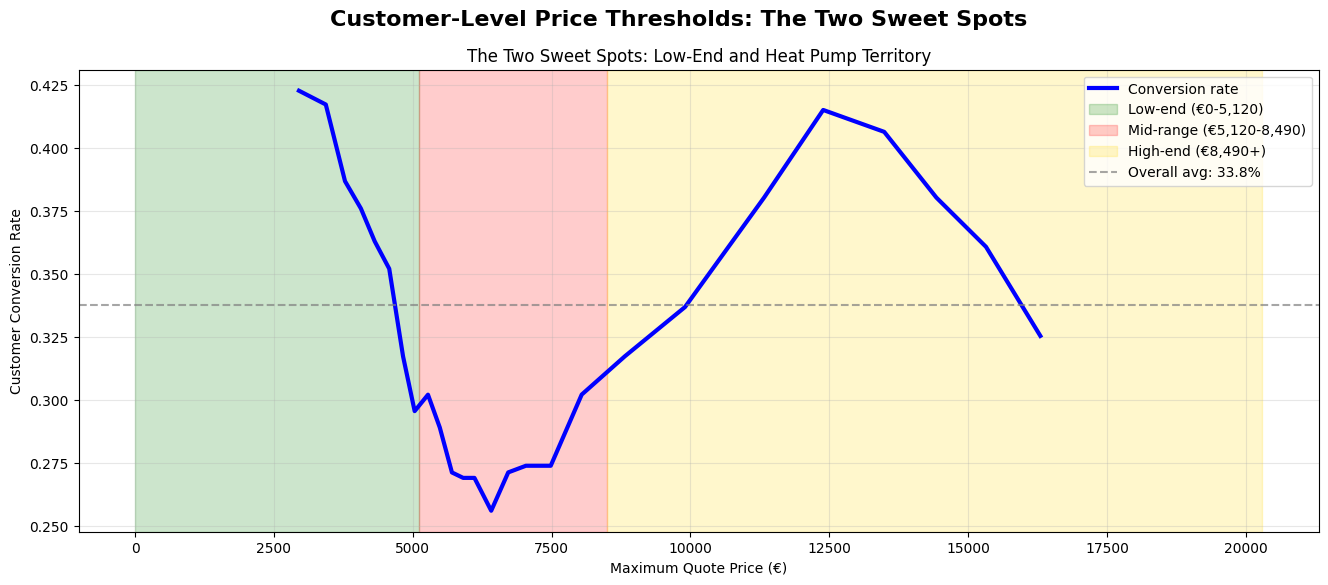

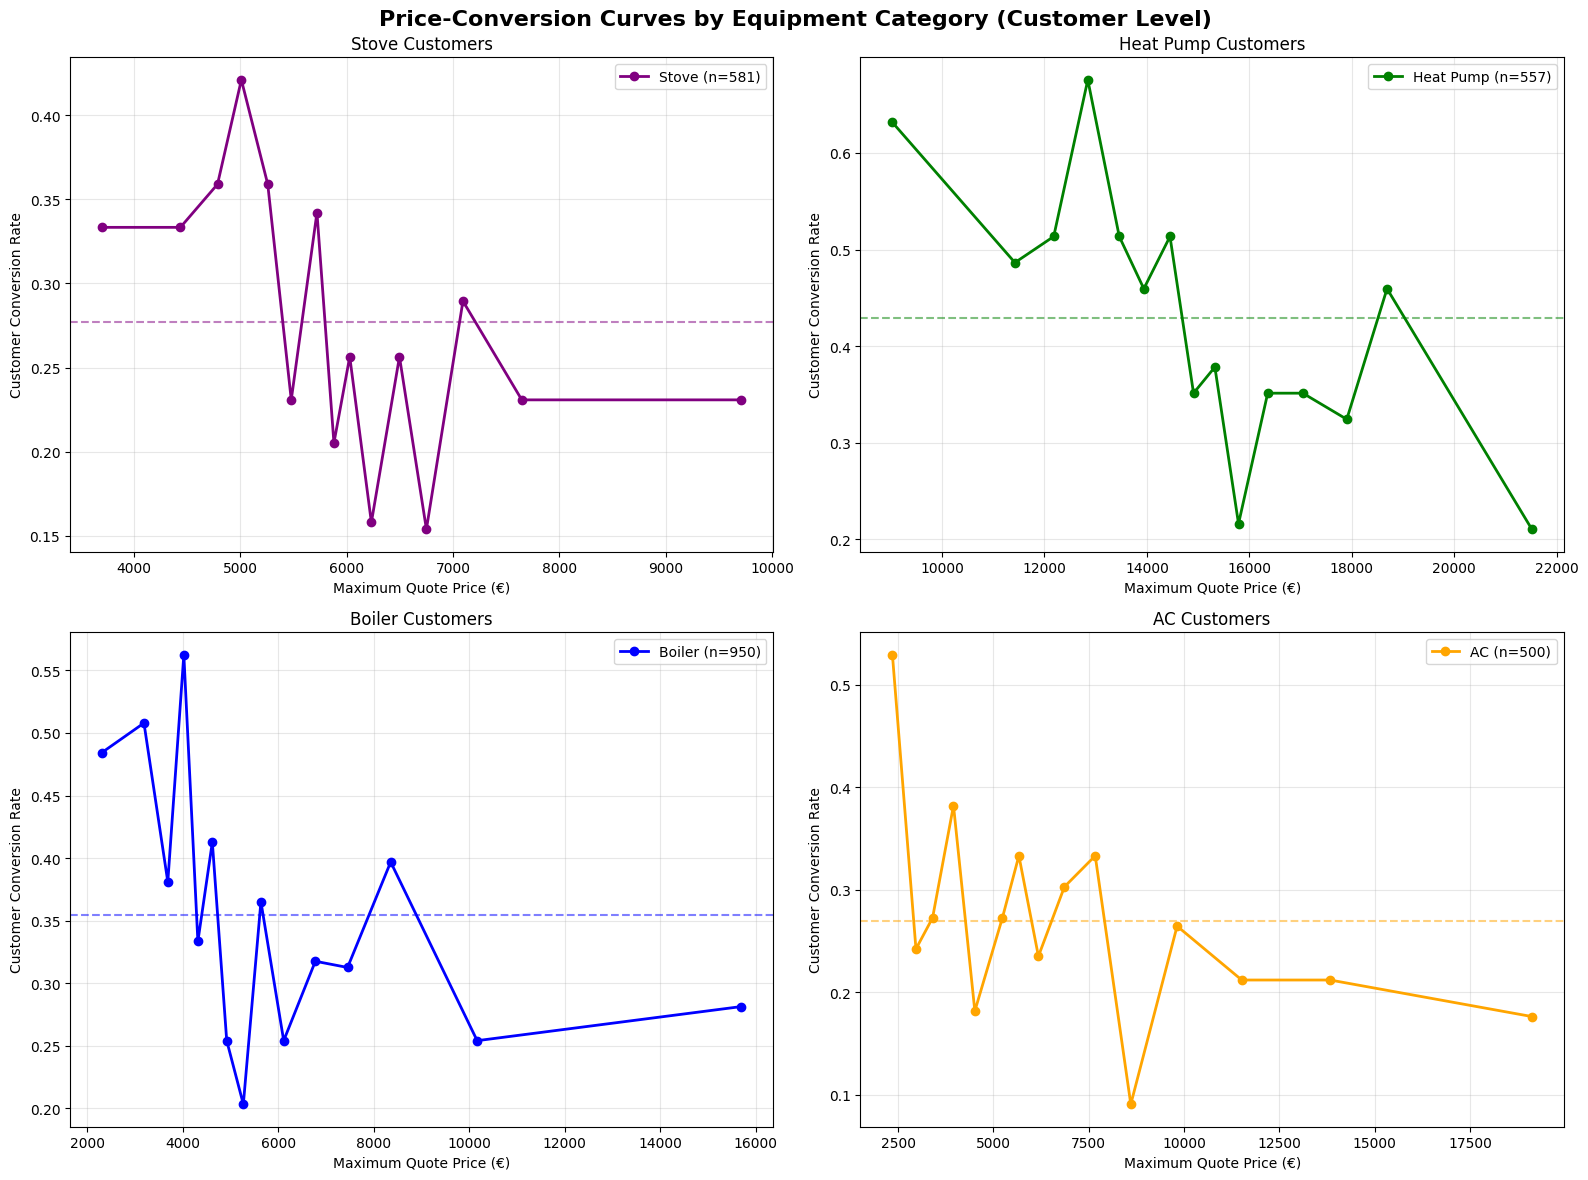


Conversion by Brand Price

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'SAUNIER DUVAL', 'MCZ', 'E.L.M. LEBLANC', 'DE DIETRICH', 'FRISQUET', 'Edilkamin']


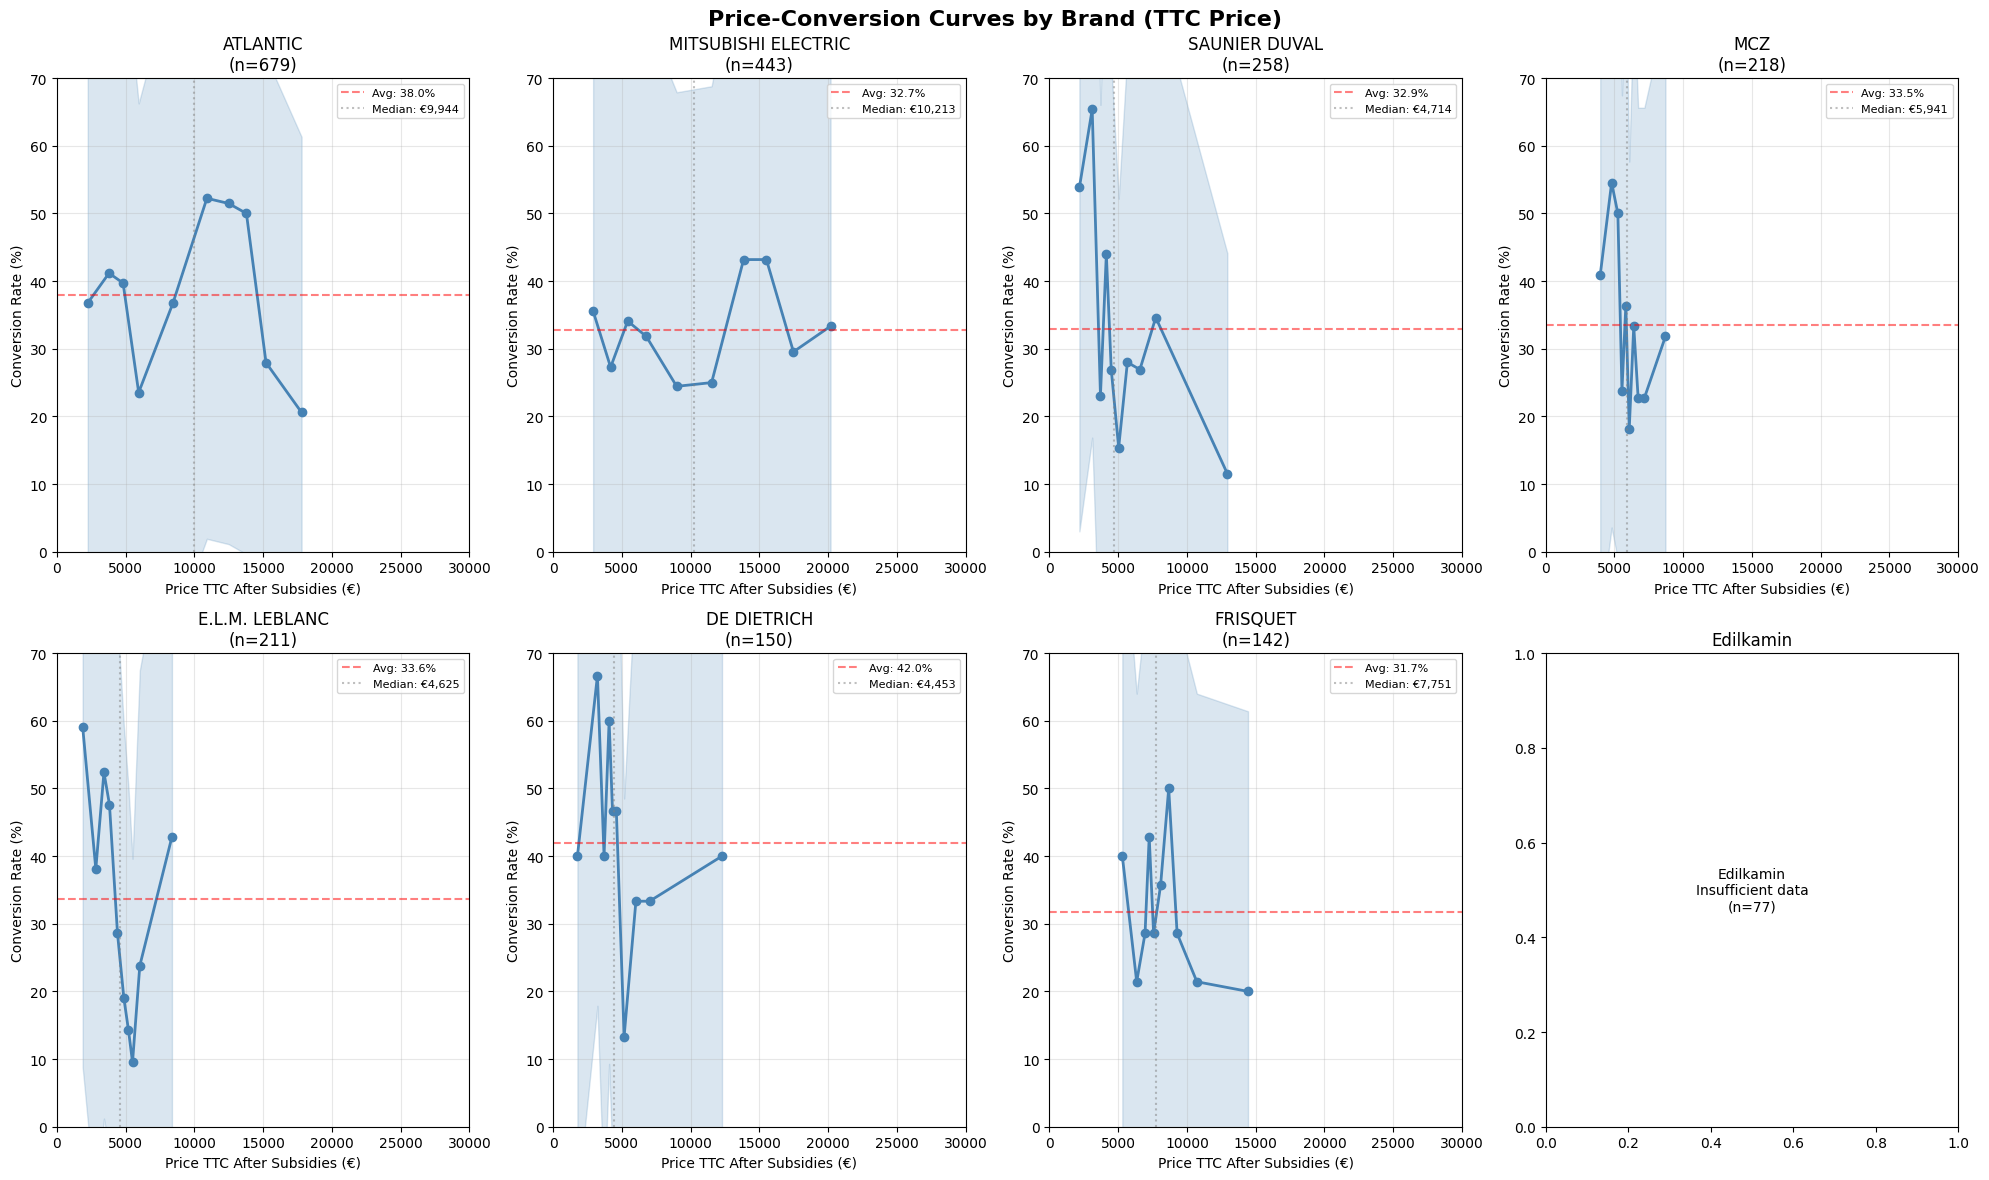


Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251


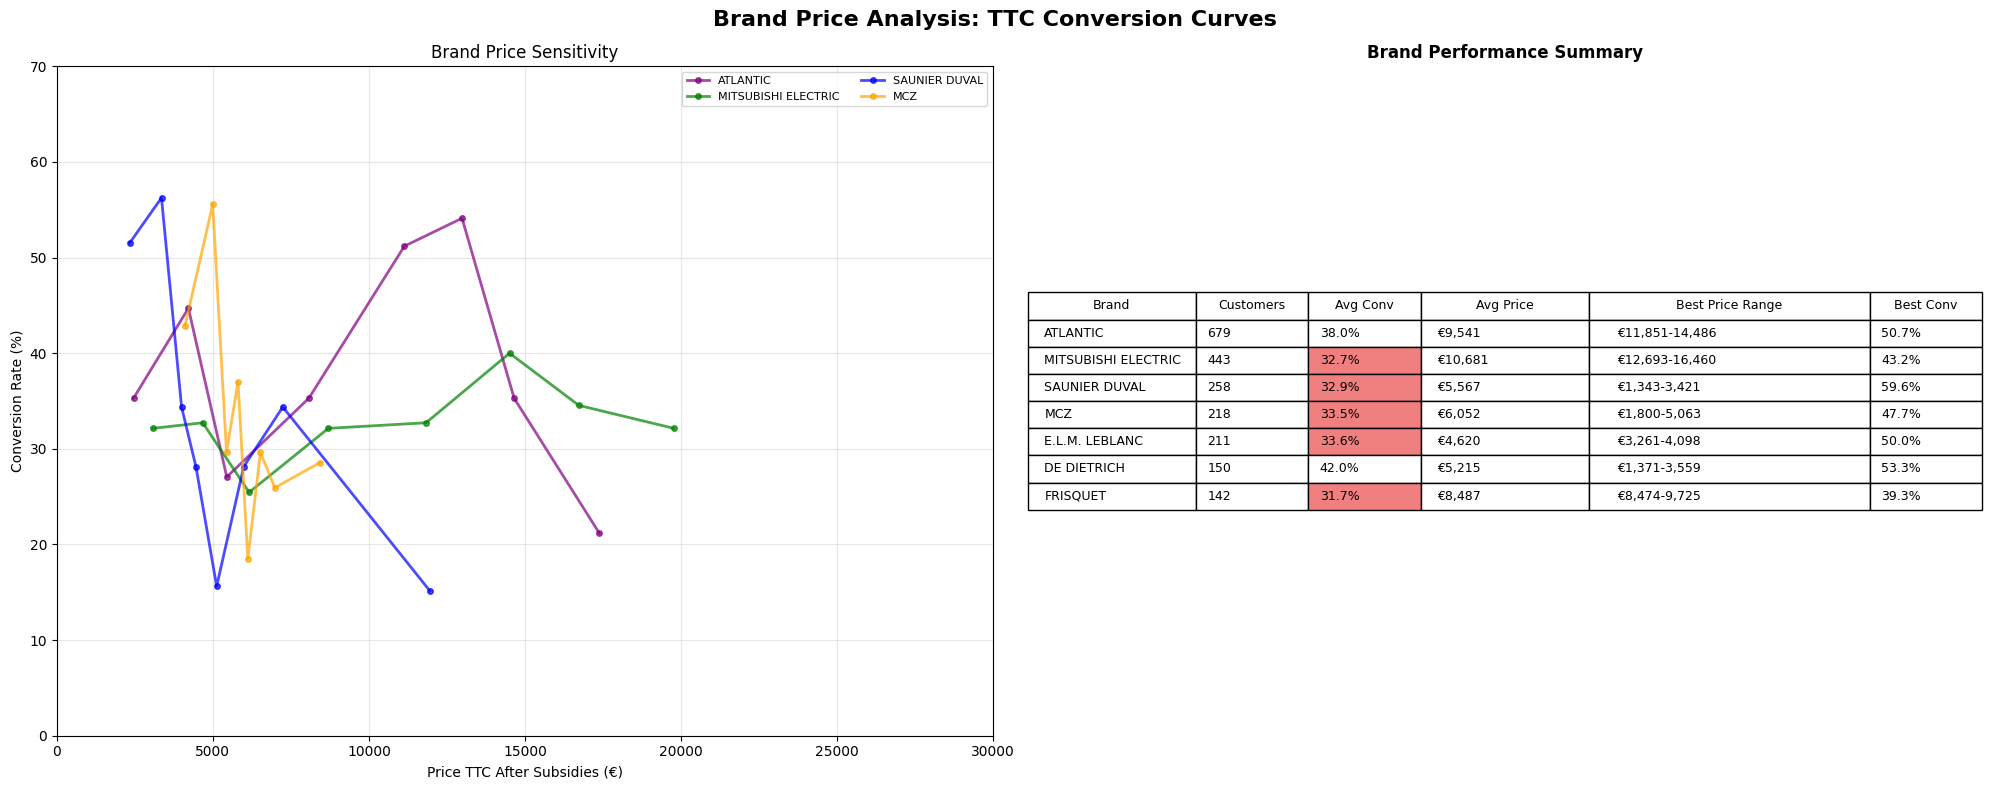


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC']

Boiler - Top brands: ['SAUNIER DUVAL', 'E.L.M. LEBLANC', 'ATLANTIC', 'FRISQUET', 'DE DIETRICH']

Stove - Top brands: ['MCZ', 'Edilkamin', 'JOLLY MEC', 'PALAZZETTI', 'ORANIER', 'DOVRE']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC']


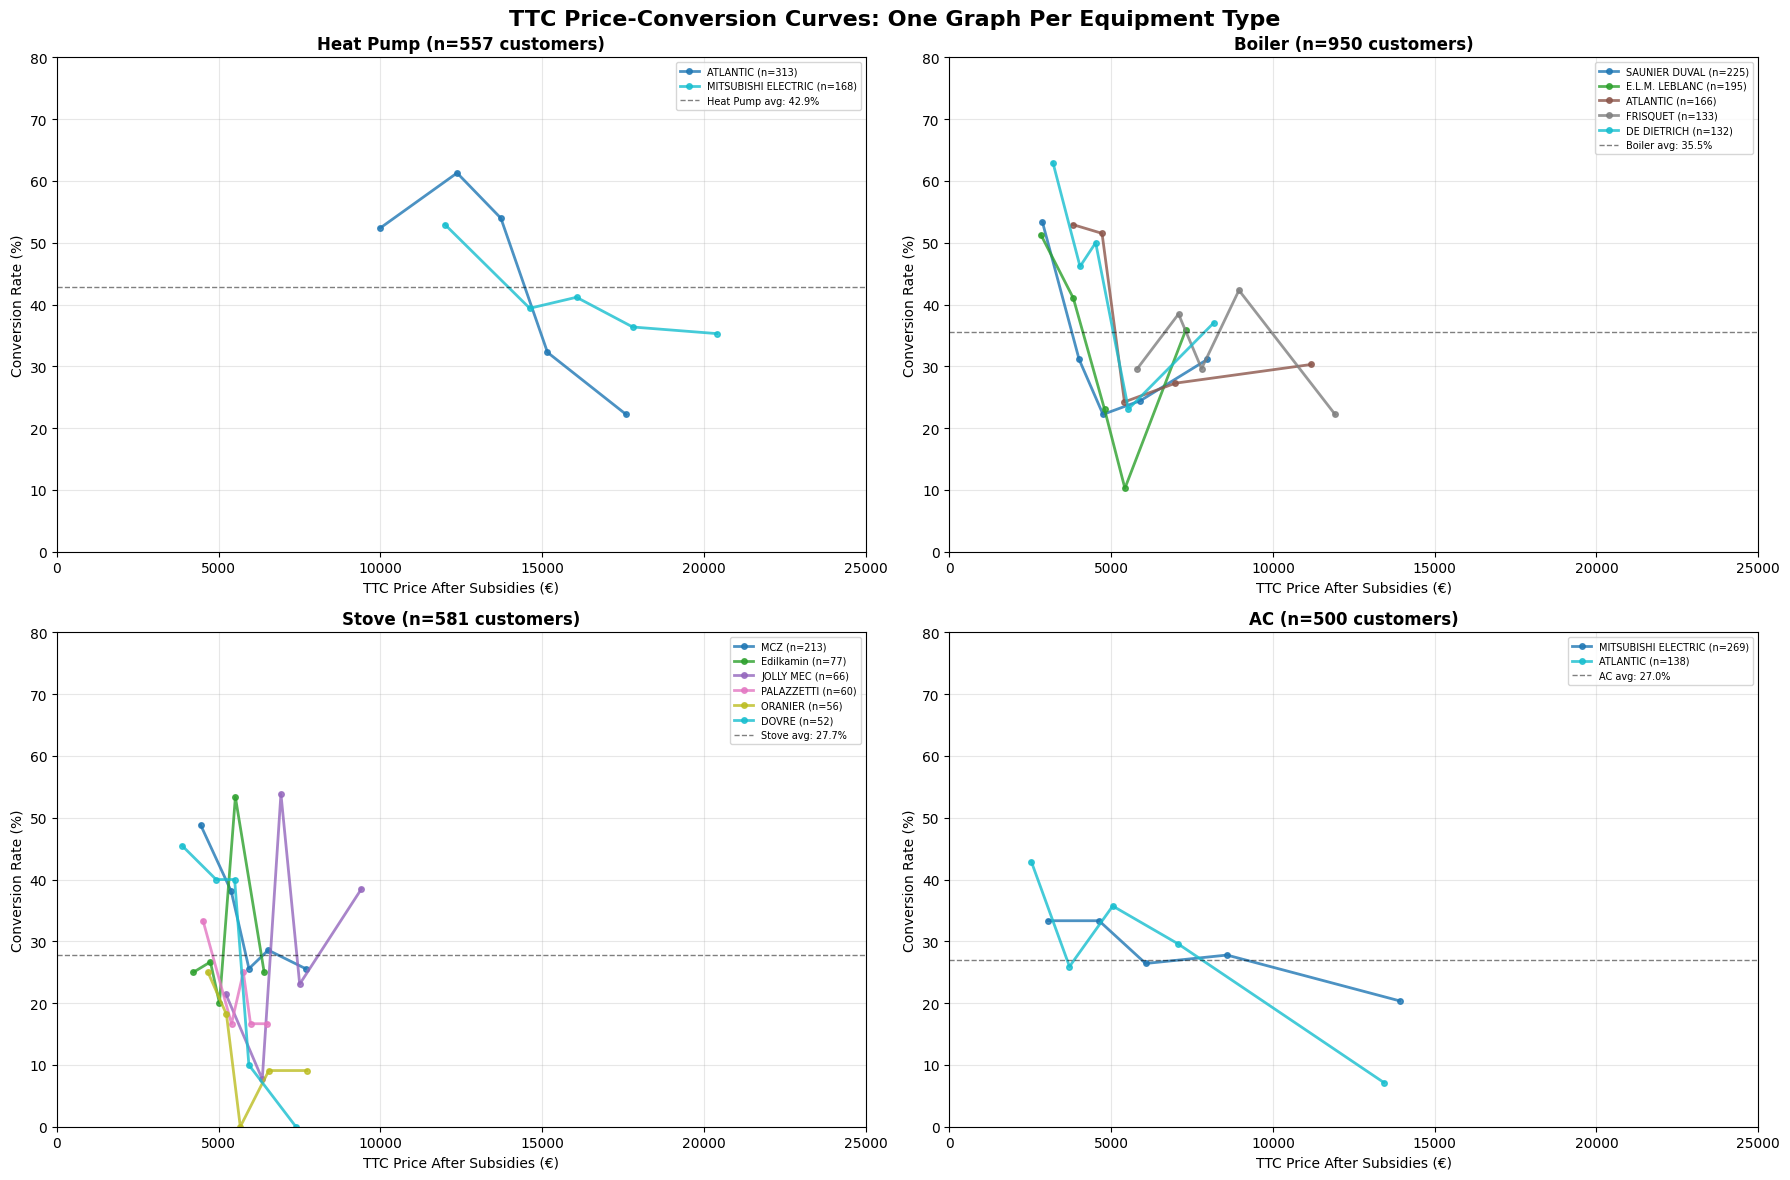


Seasonal Effects on Customer Conversion


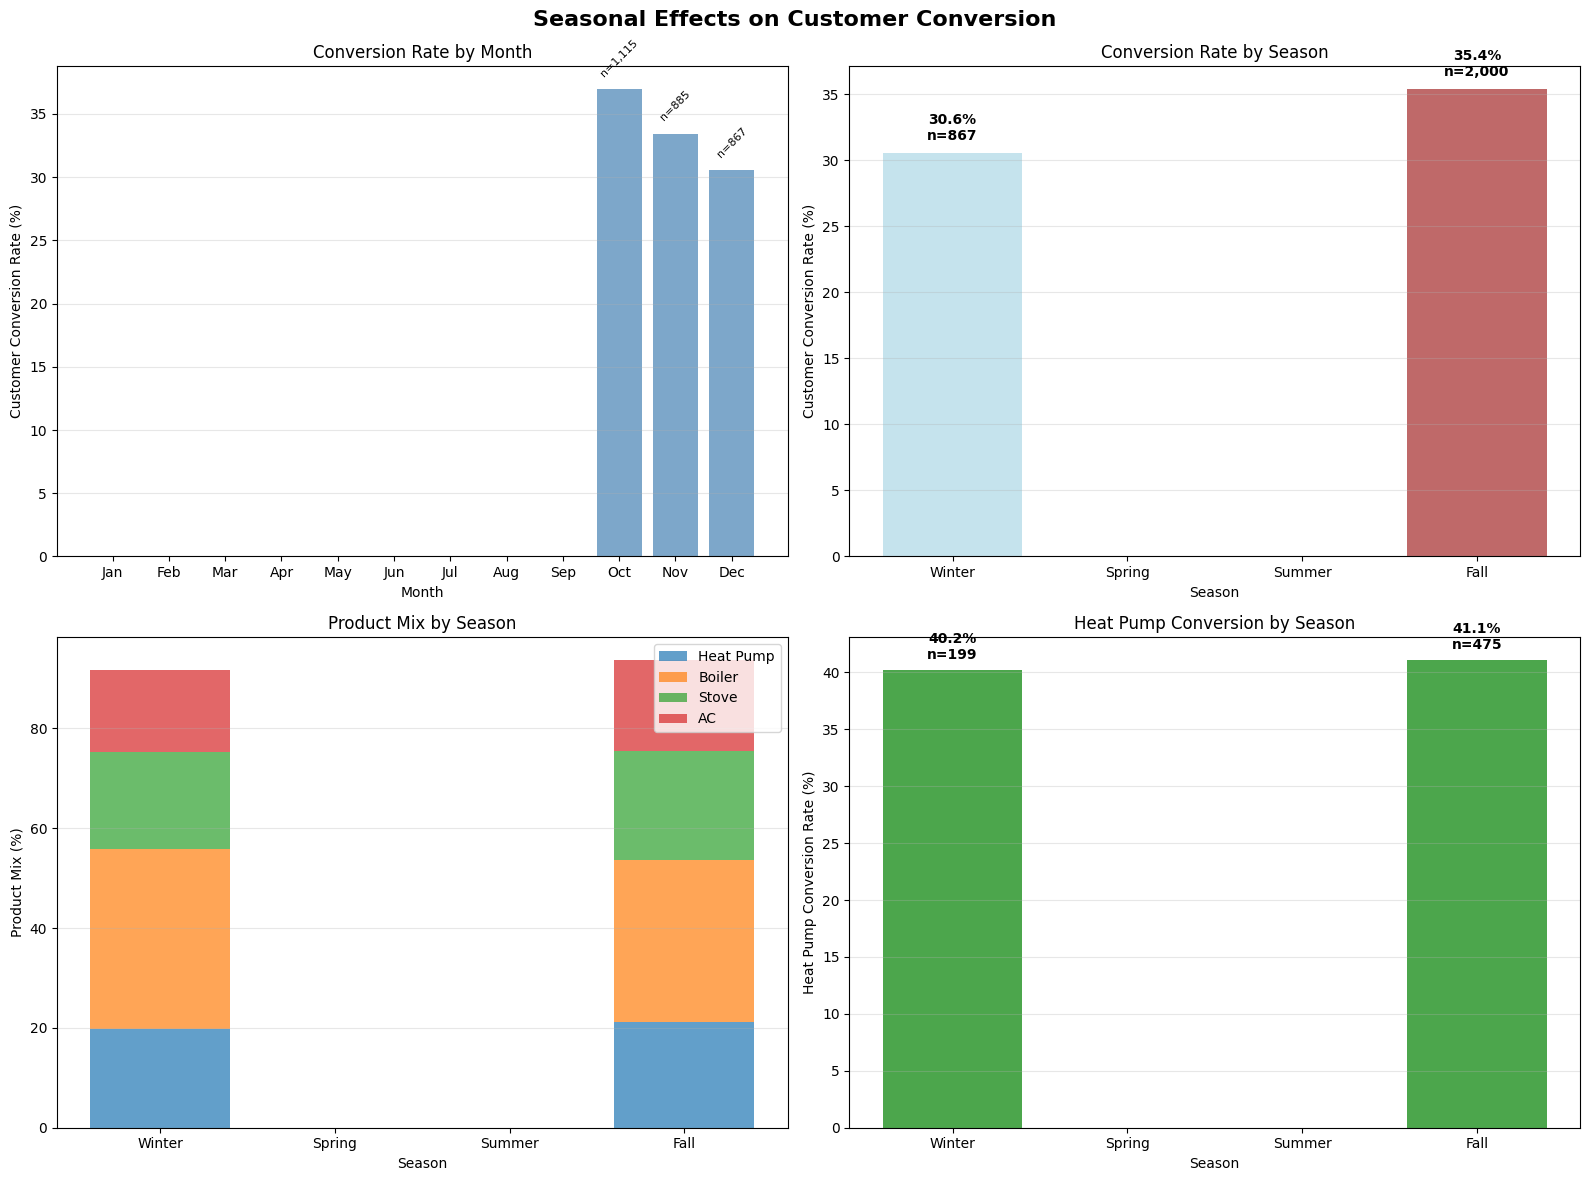


SEASONAL STATISTICS

Conversion by season:
  Winter: 30.6% (n=867)
  Fall: 35.4% (n=2,000)

Seasonality chi-square p-value: 0.0136
Statistically significant: YES

Regional Seasonal Pattern

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

Top regions: ['Auvergne-Rhône-Alpes', 'Normandie', 'Hauts-de-France']


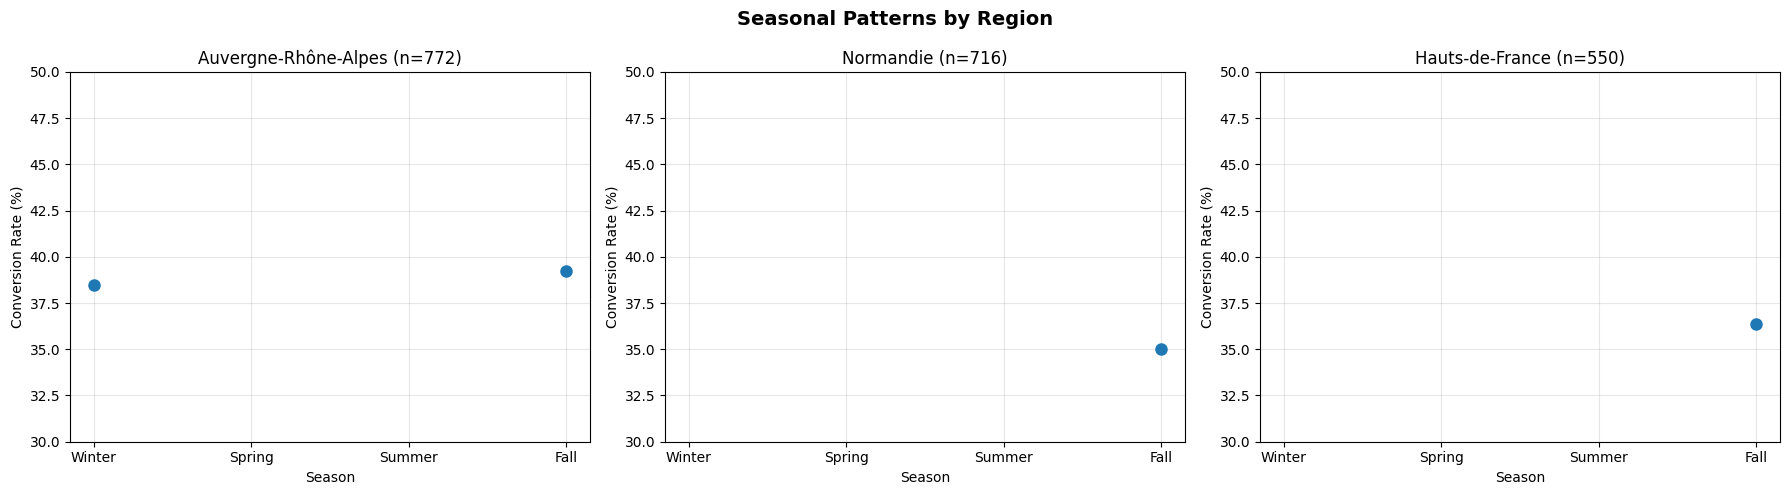


Year-over-year trends

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

Quarterly conversion rates:
                  mean  count
year_quarter                 
2025Q4        0.337676   2763


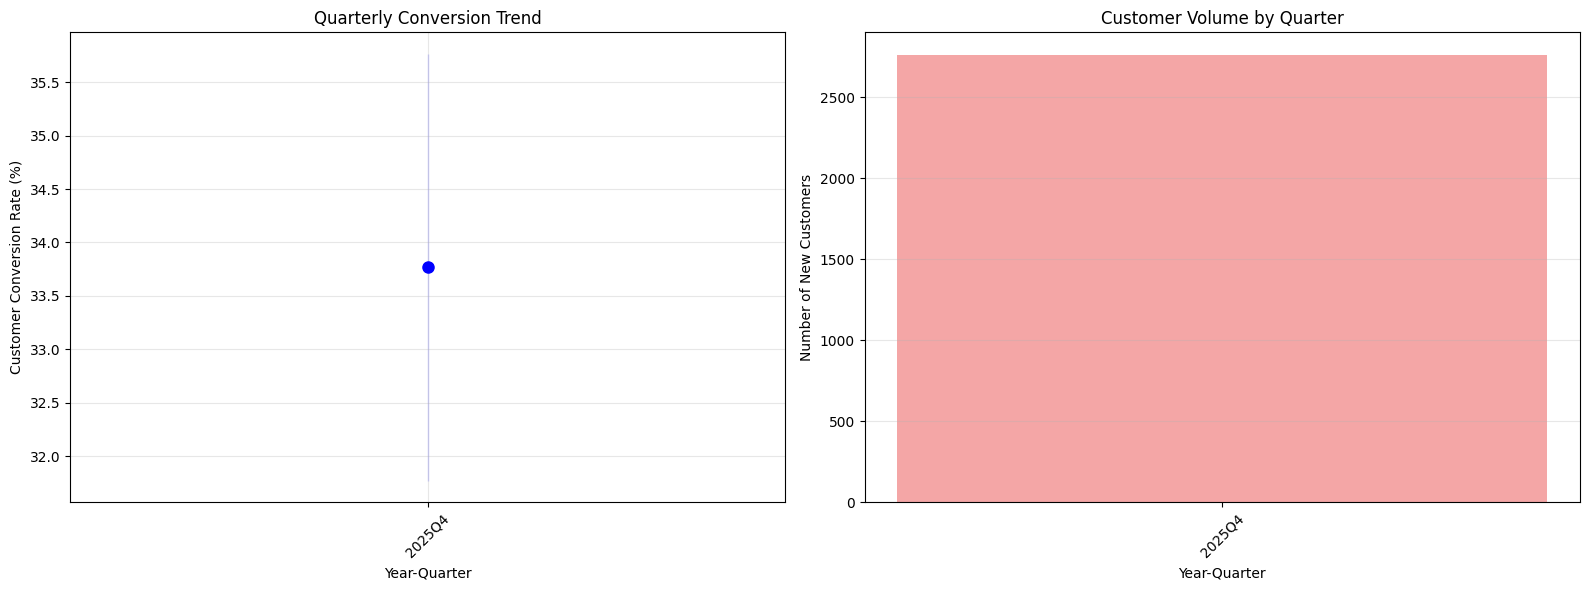


Best and Worst Months Report

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

⚠️  Only one suspension period found: [False]
Skipping suspension comparison

Best month: 10 (37.0%, n=1076)

Best season: Fall (35.1%)
Worst season: Winter (30.7%)

Heat pump conversion by season:
  Winter: 41.0%
  Fall: 42.2%

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251


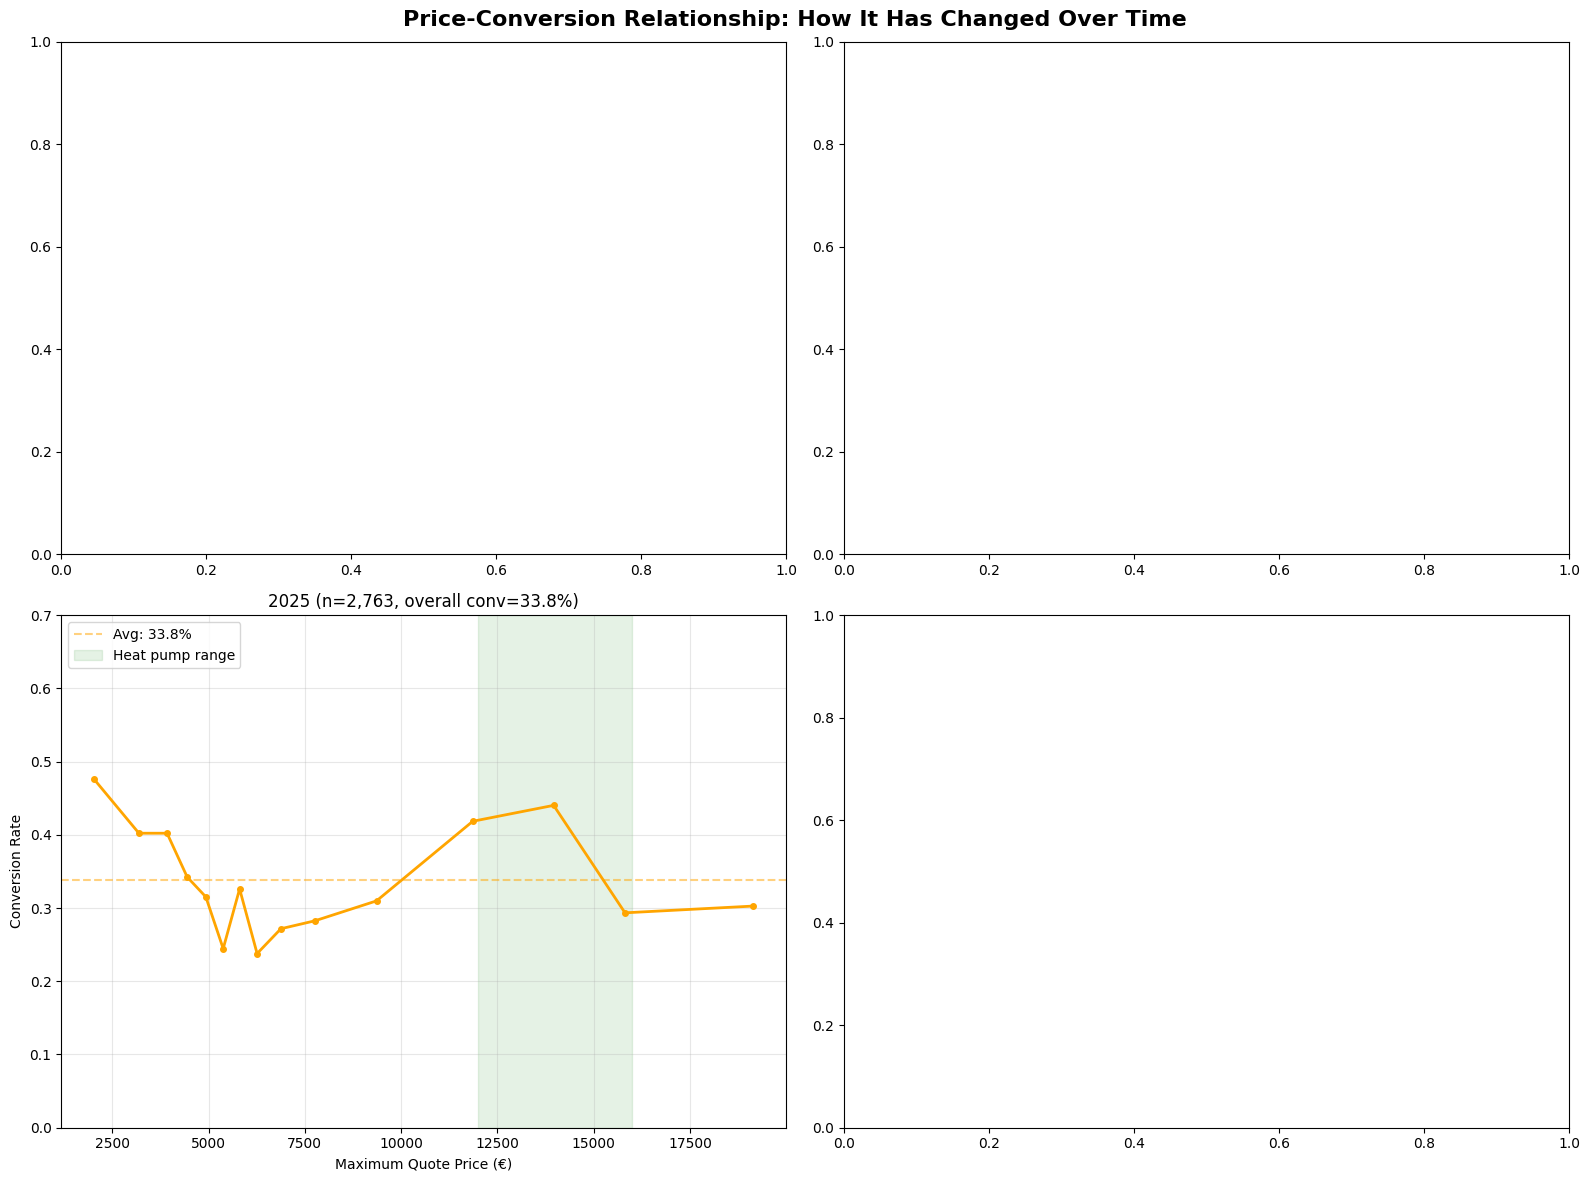


Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251


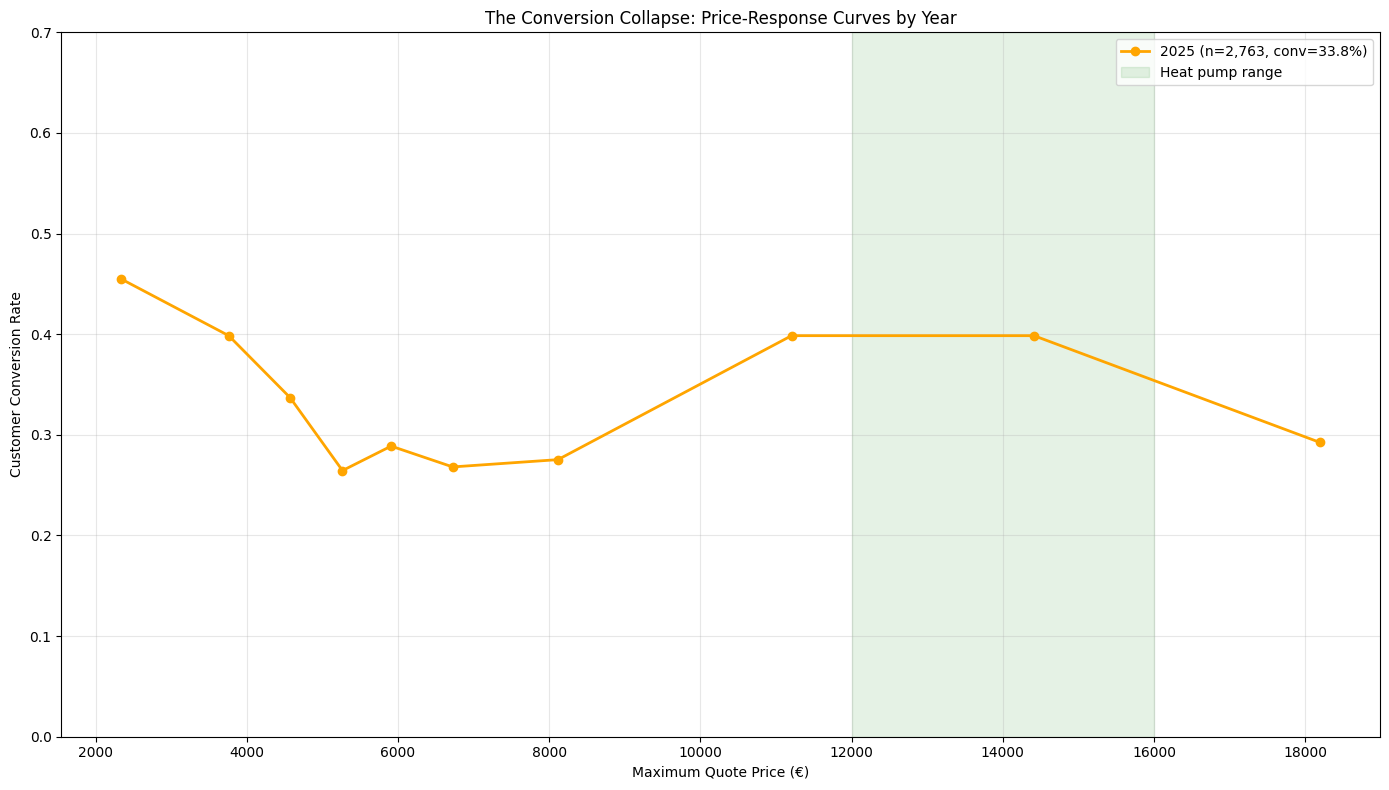


Sweet Spot Analysis Over Time

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

Sweet spots by year (price points with conversion > avg + 3%):

2025 (overall avg: 33.8%):
  €1,849: 48.2% (n=139)
  €2,832: 42.8% (n=138)
  €3,999: 43.5% (n=138)
  €12,149: 43.5% (n=138)
  €13,714: 44.2% (n=138)


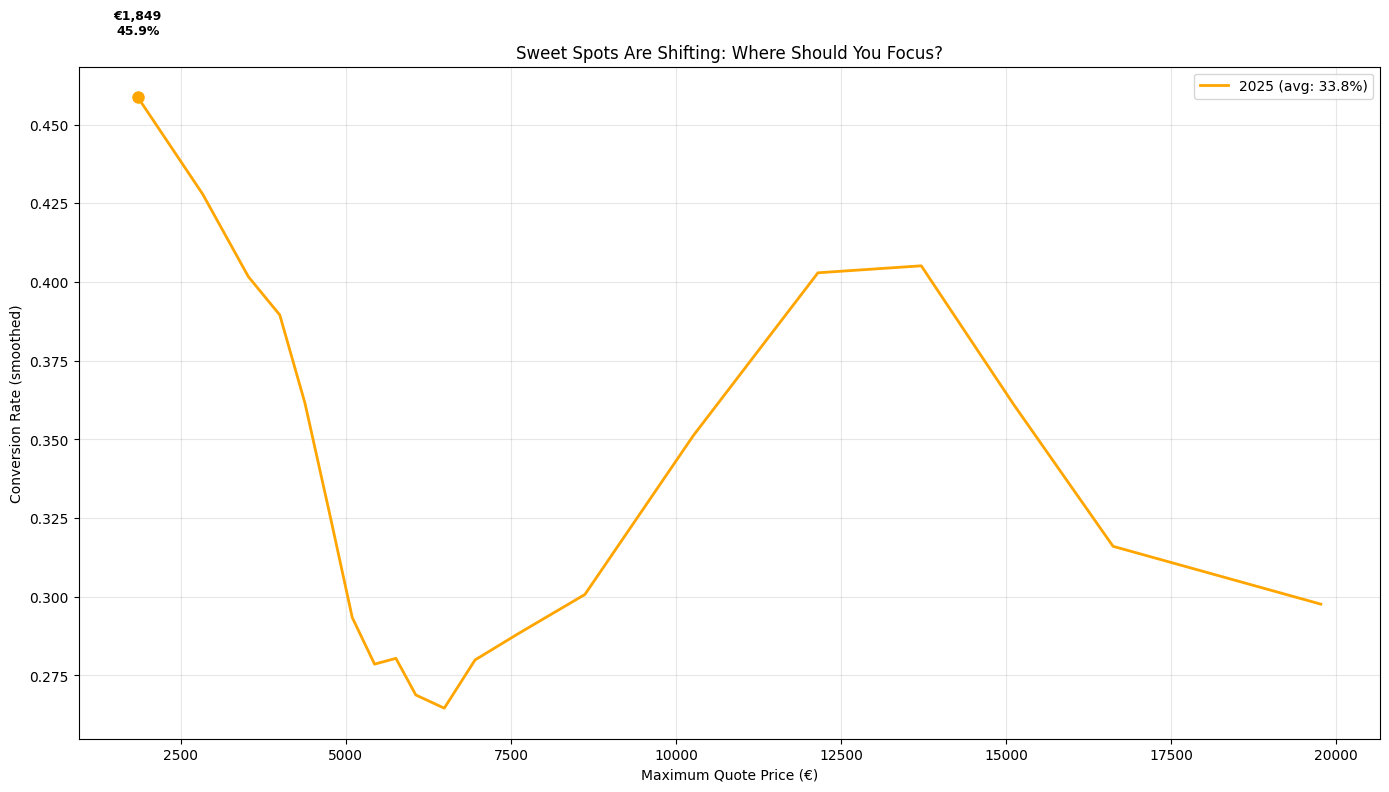


Administrative Uncertainty Effect

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

Decision time distribution:
count    2763.000000
mean        3.002895
std         8.847611
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       106.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 2,436 (88.2%)


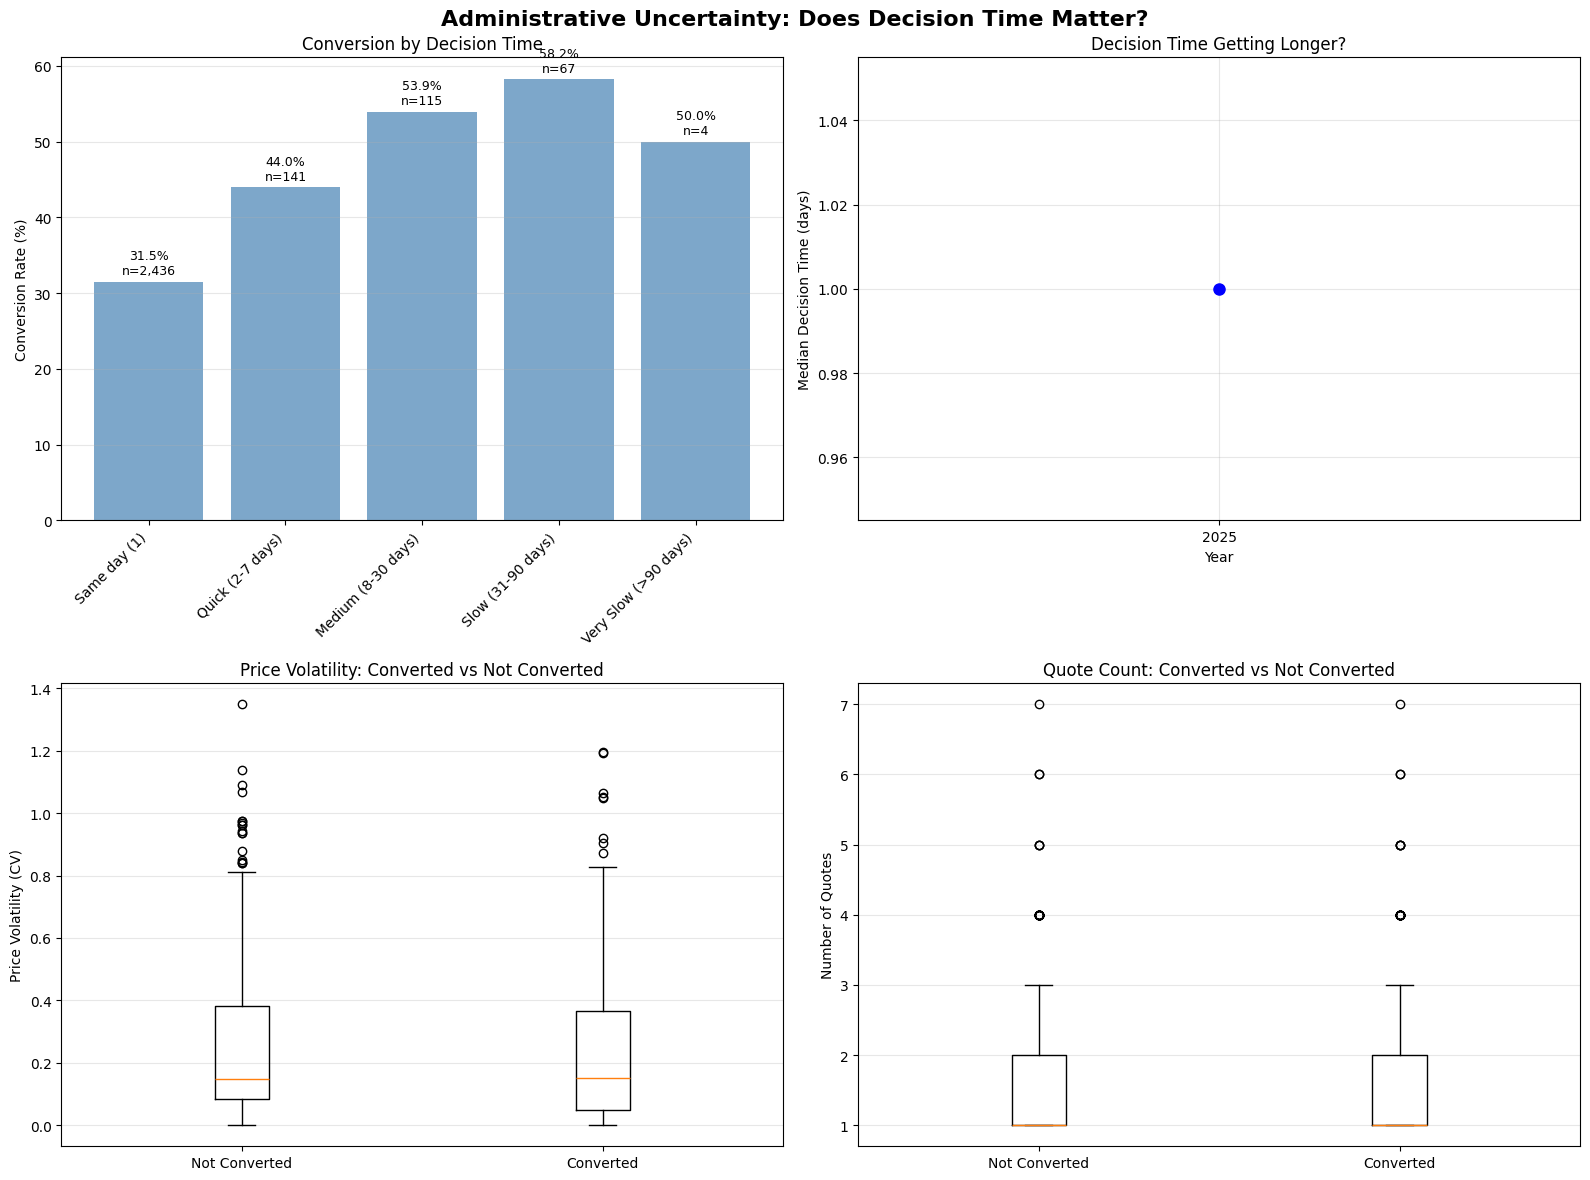


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1101.459, 4150.01]  (4150.01, 5586.29]  \
main_equipment_category                                            
AC                                 36.153846           25.609756   
Boiler                             49.019608           29.181495   
Heat Pump                           0.000000                 NaN   
Other                              45.454545           16.666667   
Stove                              36.363636           34.020619   
Unknown                            50.000000            0.000000   

price_bin_simple         (5586.29, 7286.95]  (7286.95, 13178.02]  \
main_equipment_category                                            
AC                                26.966292            21.527778   
Boiler                            33.870968            31.693989   
Heat Pump                         60.000000            58.865248   
Other                             30.769231           

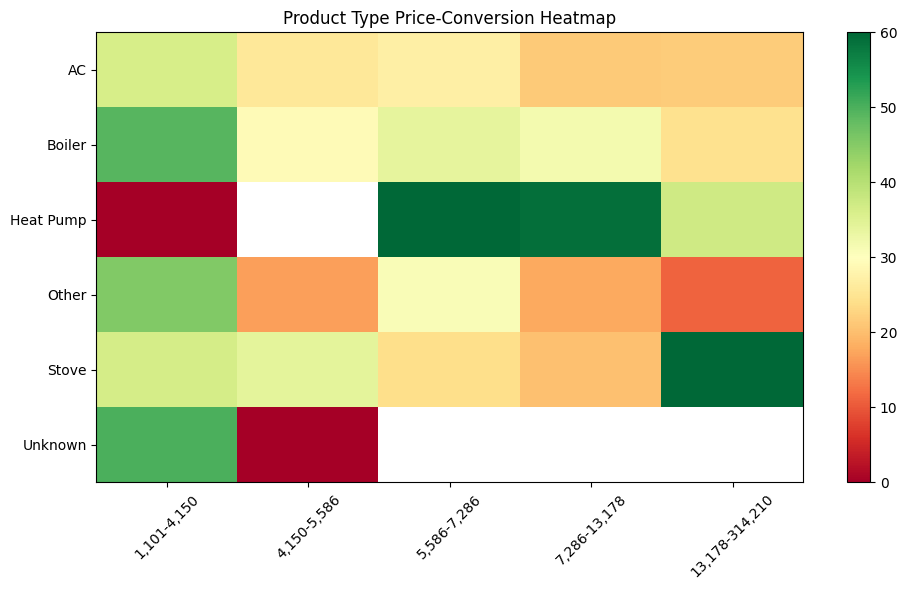


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           968
Poêle                               604
Pompe à chaleur                     531
Climatisation                       493
ECS : Chauffe-eau ou adoucisseur    128
Appareil hybride                     54
Photovoltaïque                       34
Autres                               21
Produit VMC                          12
Emetteur de chauffage  ou chappe     11
Plomberie Sanitaire                   8
Unknown                               3
Name: count, dtype: int64

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251


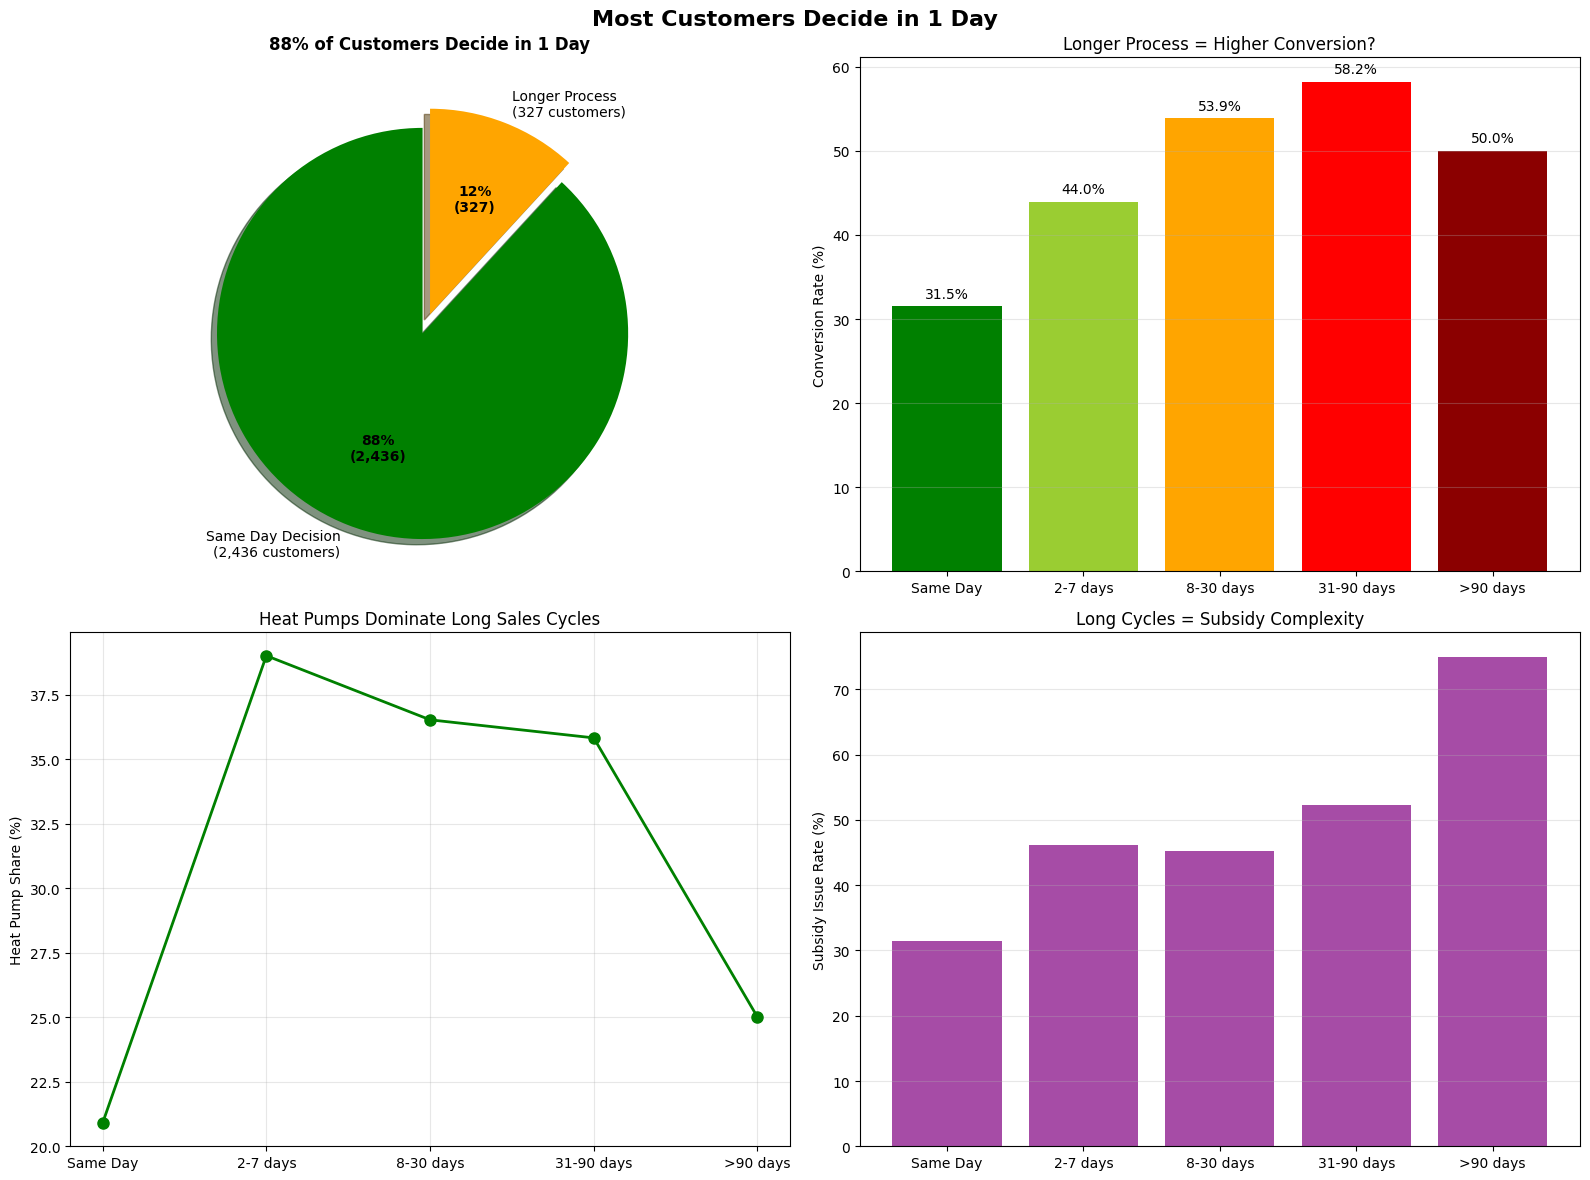


Heat Pump Performance Over Time

Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2025              0.418             631  14952.297               0.861


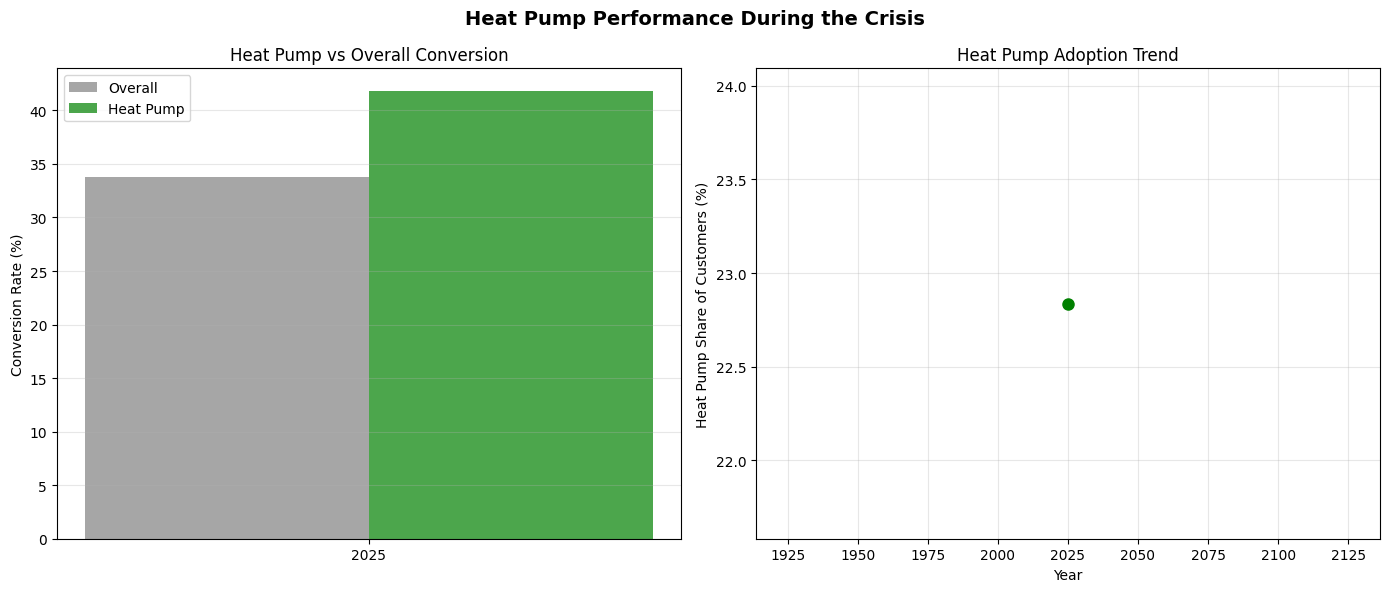


Analyzing 2,763 customers
Price range: €1,343 to €25,369
Median price: €6,251

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €2.4k (47.8%) and €1.6k (47.3%)
Dead zone: €6.0k-6.3k (22-27%)
Heat pumps: 86% subsidy issues, 41.8% conversion
Price sensitivity: Heat Pump (24.3pts) > Boiler (17.2pts) > AC (15.2pts) > Stove (13.0pts)
Same day decisions: 88%


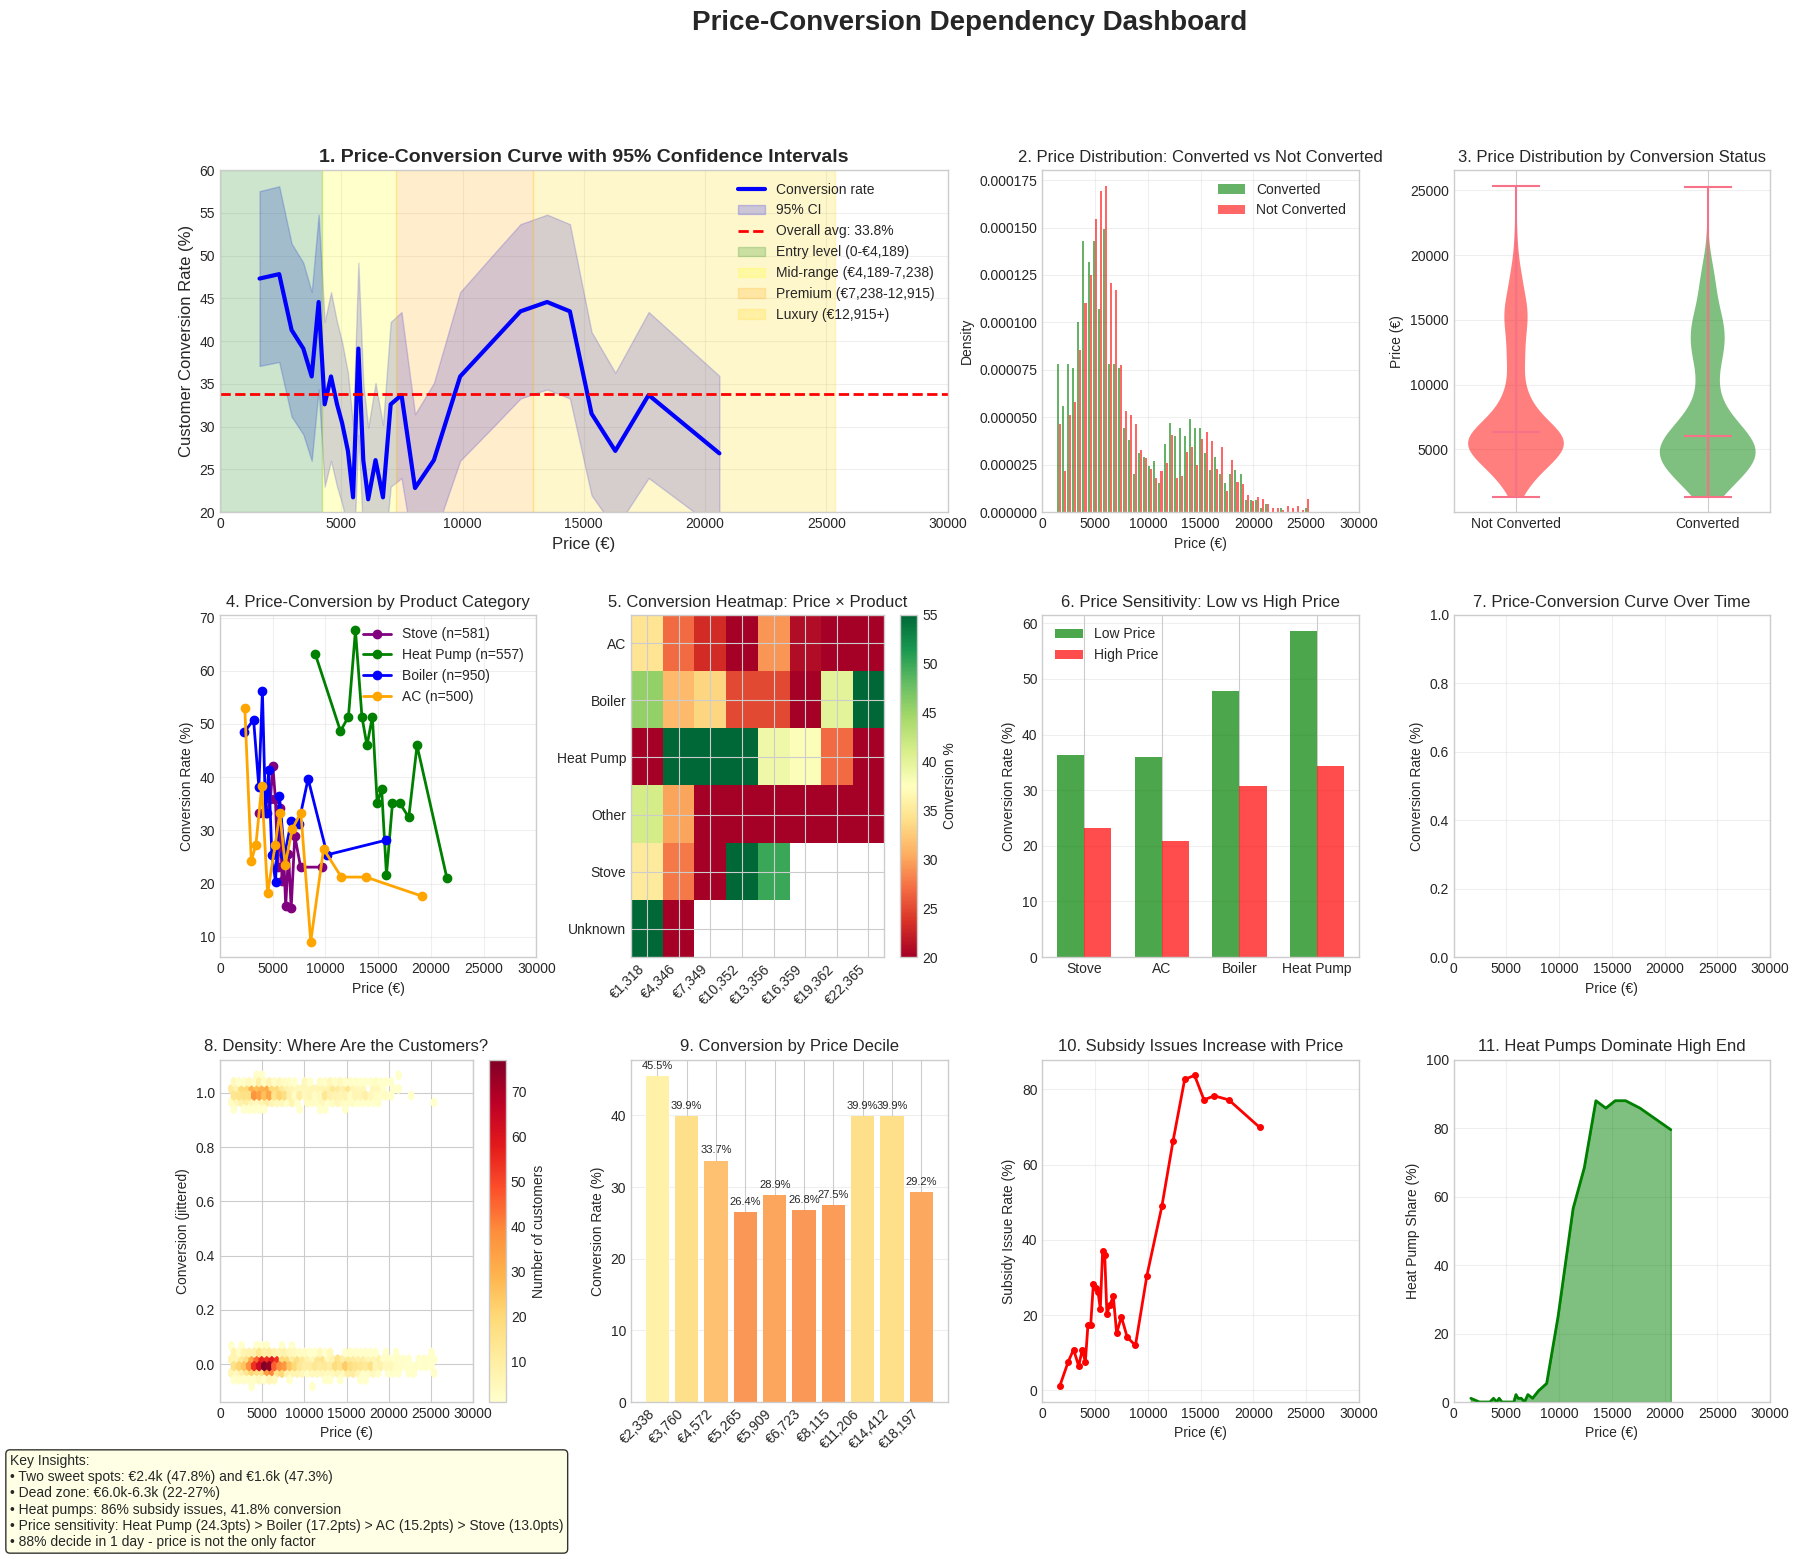

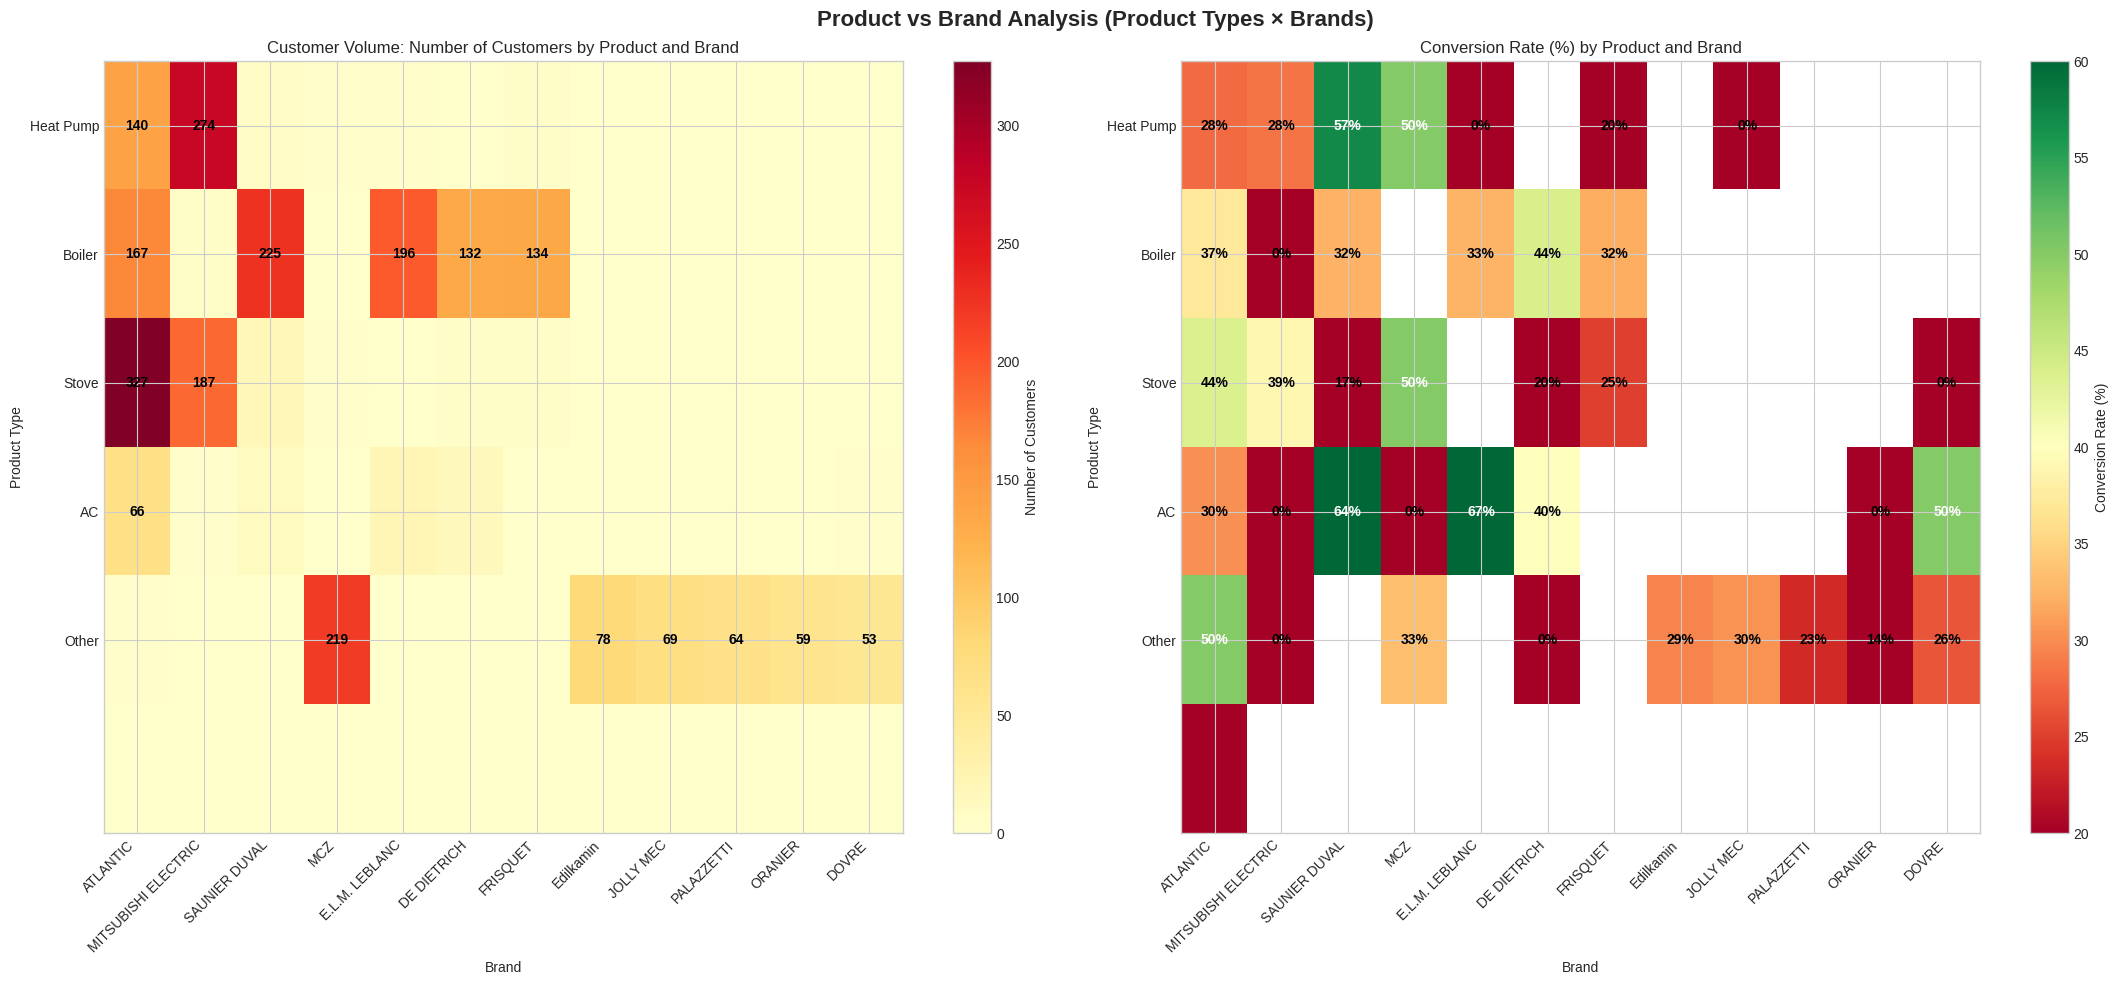


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC  SAUNIER DUVAL  MCZ  E.L.M. LEBLANC  DE DIETRICH  FRISQUET  Edilkamin  JOLLY MEC  PALAZZETTI  ORANIER  DOVRE
main_equipment_category                                                                                                                                            
AC                            140                  274              7    2               2            0         5          0          1           0        0      0
Boiler                        167                    4            225    0             196          132       134          0          0           0        0      0
Heat Pump                     327                  187             18    2               0            5         4          0          0           0        0      1
Other                          

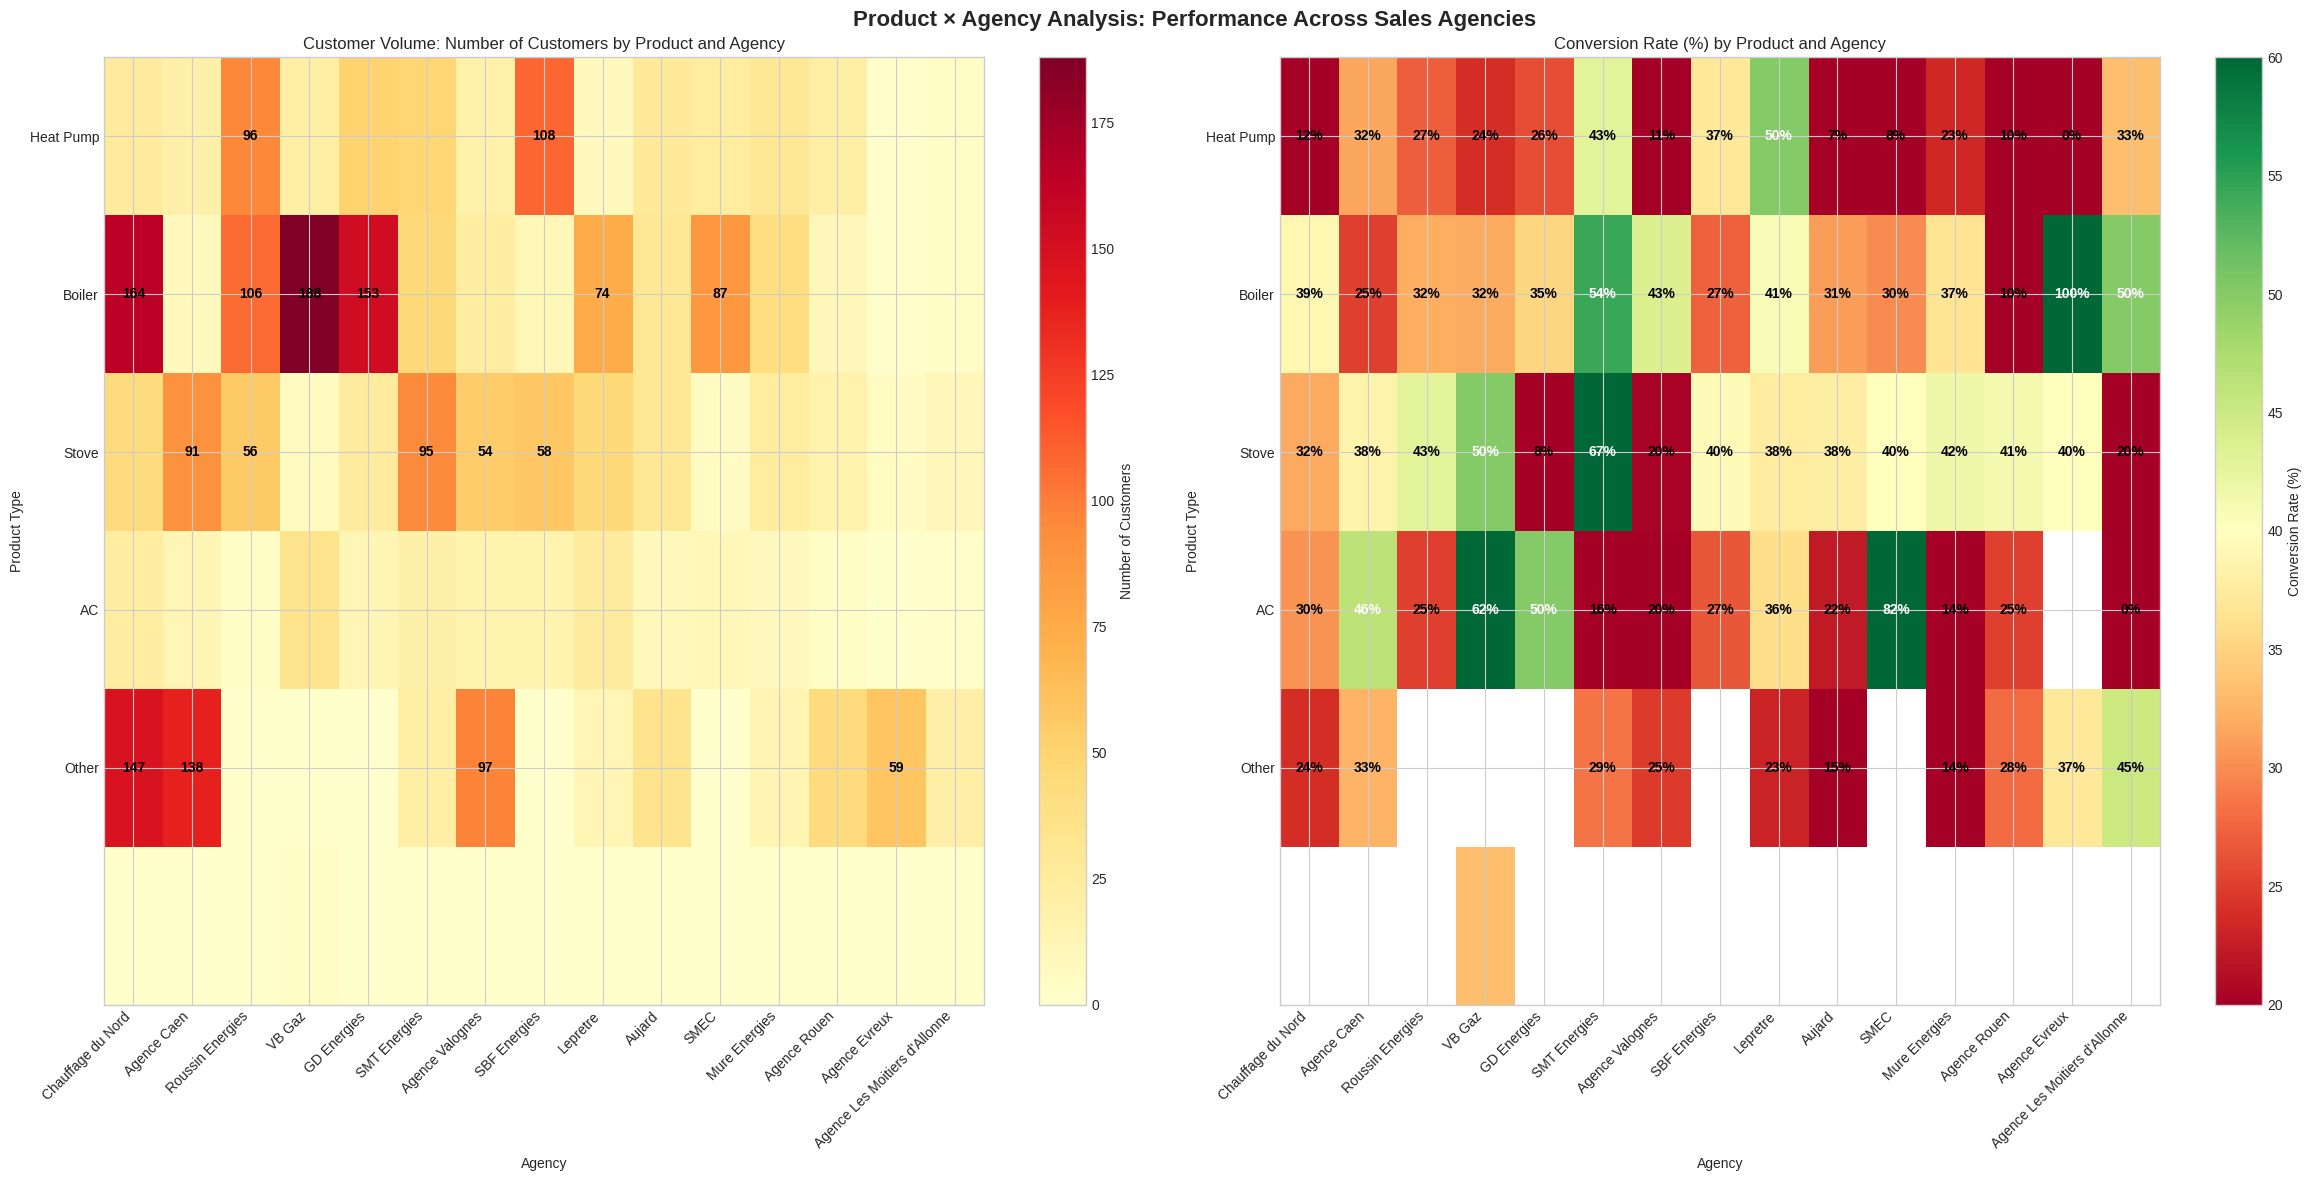


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              Chauffage du Nord  Agence Caen  Roussin Energies  VB Gaz  GD Energies  SMT Energies  Agence Valognes  SBF Energies  Lepretre  Aujard  SMEC  Mure Energies  Agence Rouen  Agence Evreux  Agence Les Moitiers d'Allonne
main_equipment_category                                                                                                                                                                                                                       
AC                                      25           19                96      21           50            49               18           108         8      27    24             30            21              1                              3
Boiler                                 164            8               106     188          153            46     

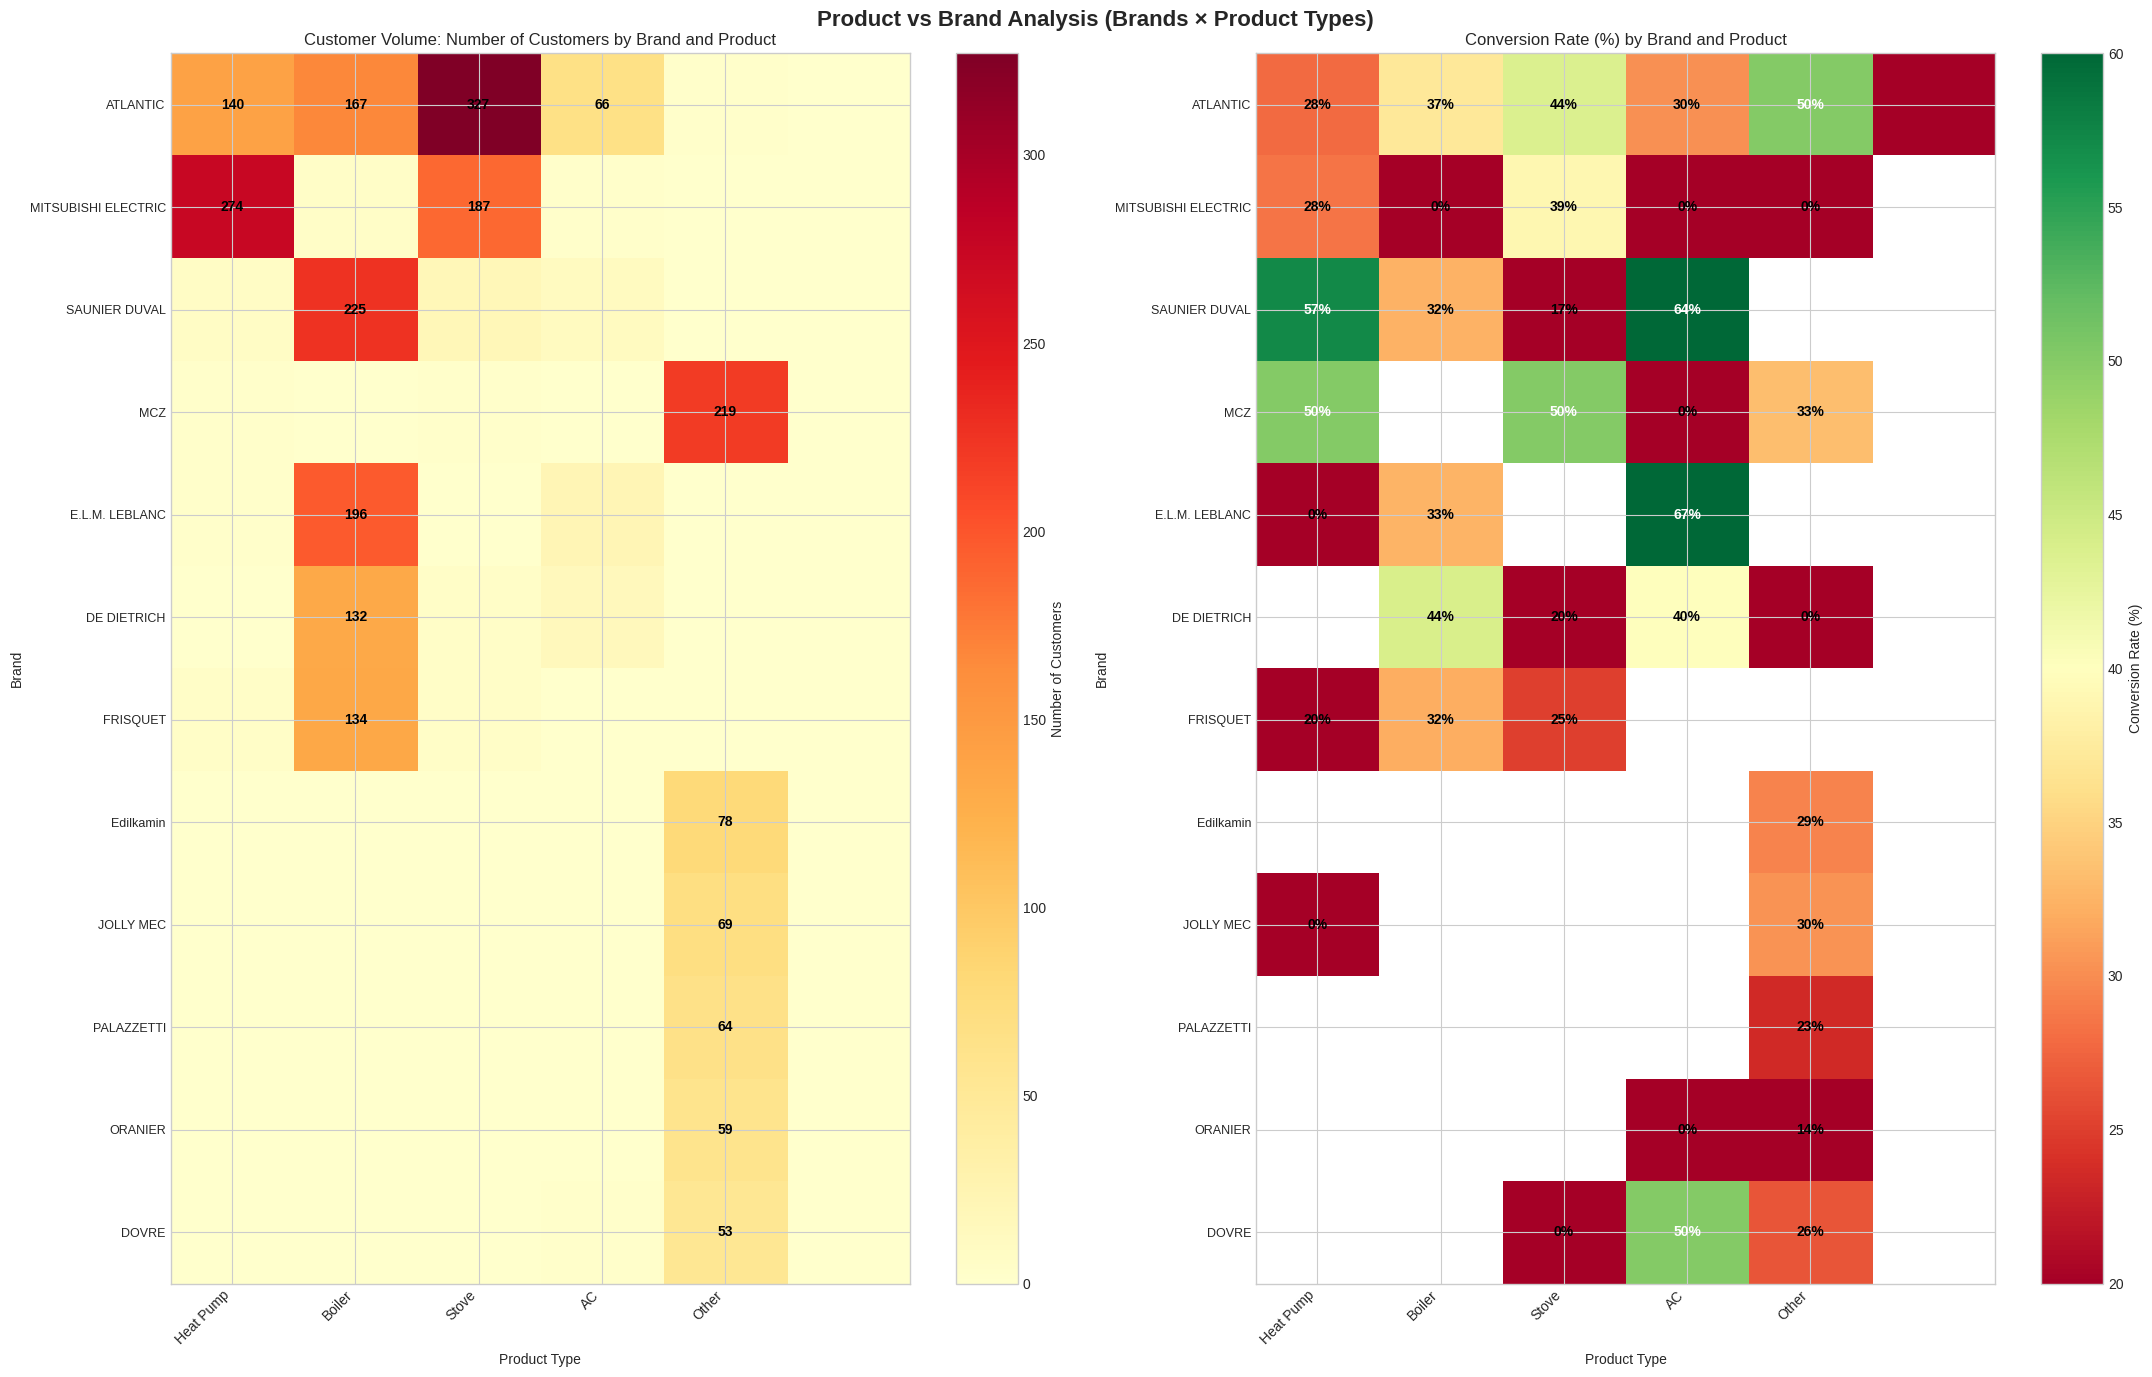


BRAND × PRODUCT ANALYSIS (Swapped Axes)

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_equipment_category   AC  Boiler  Heat Pump  Other  Stove  Unknown
main_brand                                                            
ATLANTIC                 140     167        327     66      2        1
MITSUBISHI ELECTRIC      274       4        187      2      1        0
SAUNIER DUVAL              7     225         18     11      0        0
MCZ                        2       0          2      1    219        0
E.L.M. LEBLANC             2     196          0     21      0        0
DE DIETRICH                0     132          5     15      1        0
FRISQUET                   5     134          4      0      0        0
Edilkamin                  0       0          0      0     78        0
JOLLY MEC                  1       0          0      0     69        0
PALAZZETTI                 0       0          0      0 

(main_equipment_category   AC  Boiler  Heat Pump  Other  Stove  Unknown
 main_brand                                                            
 ATLANTIC                 140     167        327     66      2        1
 MITSUBISHI ELECTRIC      274       4        187      2      1        0
 SAUNIER DUVAL              7     225         18     11      0        0
 MCZ                        2       0          2      1    219        0
 E.L.M. LEBLANC             2     196          0     21      0        0
 DE DIETRICH                0     132          5     15      1        0
 FRISQUET                   5     134          4      0      0        0
 Edilkamin                  0       0          0      0     78        0
 JOLLY MEC                  1       0          0      0     69        0
 PALAZZETTI                 0       0          0      0     64        0
 ORANIER                    0       0          0      1     59        0
 DOVRE                      0       0          1      2     53  

In [6]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)

visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')

visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')

visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')

visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')

show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)
show_brand_by_product_type_heatmap(customers)

In [7]:
import ipynbname
import subprocess
import os
import sys

def export_notebook_to_pdf(overwrite=True, verbose=True):
    """
    Export current notebook to PDF with overwrite control
    
    Args:
        overwrite (bool): If True, overwrite existing PDF file
        verbose (bool): If True, print progress messages
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Get notebook path
        notebook_path = ipynbname.path()
        notebook_path_str = str(notebook_path)
        pdf_path = notebook_path_str.replace('.ipynb', '.pdf')
        
        if verbose:
            print(f"📓 Notebook: {notebook_path.name}")
            print(f"📄 PDF path: {pdf_path}")
        
        # Check if PDF exists
        if os.path.exists(pdf_path):
            if overwrite:
                if verbose:
                    print(f"🗑️ Removing existing PDF: {pdf_path}")
                os.remove(pdf_path)
            else:
                if verbose:
                    print(f"⚠️ PDF already exists and overwrite=False")
                return False
        
        # Convert to PDF
        if verbose:
            print("🔄 Converting to PDF...")
        
        result = subprocess.run([
            'jupyter', 'nbconvert', '--to', 'pdf',
            '--no-prompt',  # Suppress input prompts
            notebook_path_str
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            if verbose:
                print(f"✅ PDF saved: {pdf_path}")
            return True
        else:
            if verbose:
                print(f"❌ Conversion failed:")
                print(result.stderr)
            return False
            
    except Exception as e:
        if verbose:
            print(f"❌ Error: {e}")
        return False

# Use the function
if __name__ == "__main__":
    # Overwrite existing PDF
    export_notebook_to_pdf(overwrite=True)
    
    # Or create new version without overwriting
    # export_notebook_to_pdf(overwrite=False)export_full_notebook_to_pdf()

📓 Notebook: _eda_price_2025_Q4.ipynb
📄 PDF path: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025_Q4.pdf
🗑️ Removing existing PDF: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025_Q4.pdf
🔄 Converting to PDF...
✅ PDF saved: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025_Q4.pdf
